# 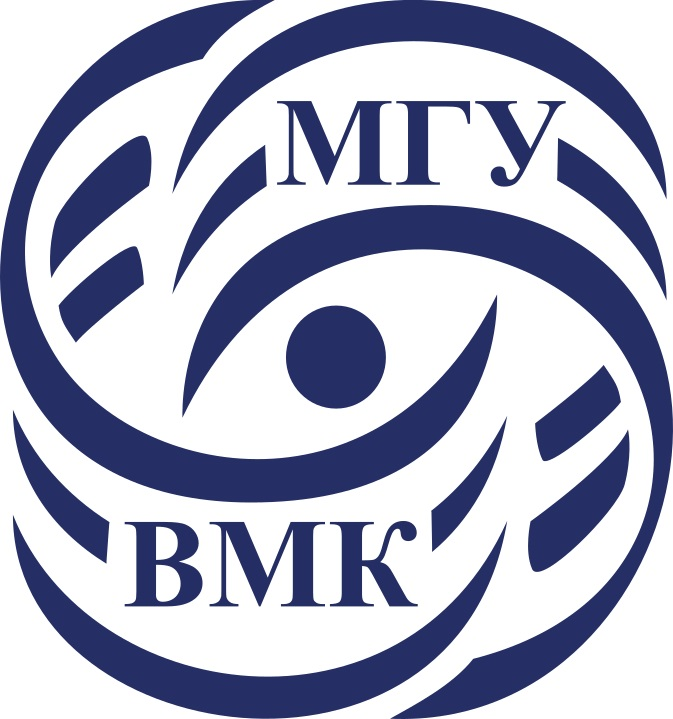

# Машинное обучение. ВМК МГУ

# Практическое задание 5: SVM
## Уровень: <font color='MediumSeaGreen'>**Исследовательский (Research)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

Цель данного задания:

* Изучите нюансы работы модели SVM
* Узнаете про метод, который позволяет понижать число признаков и изучите его особенности на практике
* Научитесь корректировать выход модели SVM-классификатора, чтобы уметь получать вероятности

-------
<font color="white" style="opacity:0.2025"></font>
<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: до 10 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)


In [1]:
! curl https://raw.githubusercontent.com/MSU-ML-COURSE/ML-COURSE-25-26/refs/heads/master/requirements/requirements.txt -o ./requirements_2025_26_for_colab_small.txt
! pip install -q -r ./requirements_2025_26_for_colab_small.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   360  100   360    0     0   1359      0 --:--:-- --:--:-- --:--:--  1363


Проверим версию библиотеки:

In [2]:
import catboost
assert(catboost.__version__ == '1.2.8')

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2025"></font>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from copy import copy

Если Вы дальтоник, то можете воспользоваться готовой colormap из matplotlib (или найти свою):
```
plt.style.use('tableau-colorblind10')
```

In [4]:
from matplotlib.colors import ListedColormap

from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, train_test_split
from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score
from sklearn.datasets import make_blobs, make_circles, make_moons

In [5]:
def make_moons_cls(size=1000, d=2):
    X, y = make_moons(n_samples=size, noise=0.15)
    if d > 2:
        X = np.concatenate((X, np.random.normal(size=(size, d-2))), axis=1)
    return X, y

def make_circles_cls():
    X, y = make_circles()

def generate_data_with_imb_classes(size1=100, size2=10):
    X = np.r_[(
        np.random.normal(loc=1.0, size=(size1, 2)),
        np.random.normal(loc=0.5, size=(size2, 2))
    )]

    y = np.ones(len(X))
    y[-size2:] = 0
    return X, y

In [6]:
def plot_separating_surface(X, y, cls, view_support=False, title=''):
    x_min = min(X[:, 0]) - 0.1
    x_max = max(X[:, 0]) + 0.1
    y_min = min(X[:, 1]) - 0.1
    y_max = max(X[:, 1]) + 0.1
    h = 0.005
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
    Z = cls.predict(np.c_[xx.ravel(), yy.ravel()])

    plt.figure(figsize=(10, 10))
    if title:
        plt.title(title)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=40, cmap=cm_bright)
    if view_support:
        plt.scatter(X[cls.support_, 0], X[cls.support_, 1],
                    c=y[cls.support_], edgecolors='k', s=150, cmap=cm_bright)
    Z = Z.reshape(xx.shape)
    plt.xticks(())
    plt.yticks(())
    plt.contourf(xx, yy, Z, cmap=cm, alpha=.3)
    plt.show()

# Загрузка данных

In [7]:
import gdown
gdown.download_folder('https://drive.google.com/drive/folders/1bp39_Jj0edo1lzxZ3DIoChsOVy5DVi1R?usp=sharing')

Retrieving folder contents


Retrieving folder 1tv605hGxdQtd4zC787DbcRF0312gDeK_ imbalanced
Processing file 14zd2xHDChSHtMWQ_TUzM8td7s8gzCO2u X_imb_test.npz.npy
Processing file 1Qed066d3gUsUOZiUZu6aCrIH9f0yWKSc X_imb.npz.npy
Processing file 1uD87Xbh4MMBBn5fsScrknI54SINIqory y_imb_test.npz.npy
Processing file 1RR2VU_6WJMLo88k8C1VzBwb2Ibnz1yJf y_imb.npz.npy
Retrieving folder 1uoI6vZWwIII1jd2k5TtsZTJ3JOkK0G6O public
Processing file 1Win7ZtHLHEbDtX6x6O7vBJHwJviQxbp5 cX_test.npy
Processing file 1MowPnLFAMEjjcAjDA4skE4OUFdmaiSY6 cX_train.npy
Processing file 1VYA4N5wCQhwteQSZkDogFTha2xRv0FgW cy_train.npy


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=14zd2xHDChSHtMWQ_TUzM8td7s8gzCO2u
To: /home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/imbalanced/X_imb_test.npz.npy
100%|██████████| 2.05k/2.05k [00:00<00:00, 5.54MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Qed066d3gUsUOZiUZu6aCrIH9f0yWKSc
To: /home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/imbalanced/X_imb.npz.npy
100%|██████████| 2.05k/2.05k [00:00<00:00, 7.36MB/s]
Downloading...
From: https://drive.google.com/uc?id=1uD87Xbh4MMBBn5fsScrknI54SINIqory
To: /home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/imbalanced/y_imb_test.npz.npy
100%|██████████| 1.09k/1.09k [00:00<00:00, 3.35MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RR2VU_6WJMLo88k8C1VzBwb2Ibnz1yJf
To: /home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/imbalanced/y_imb.npz.npy
100%|█████

['/home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/imbalanced/X_imb_test.npz.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/imbalanced/X_imb.npz.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/imbalanced/y_imb_test.npz.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/imbalanced/y_imb.npz.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/public/cX_test.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/public/cX_train.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/research/05-SVM/public/cy_train.npy']

Перед выполнение данного ноутбука рекомендуем просмотреть базовый ноутбук по SVM

# Форма разделяющей поверхности для несбалансированных классов

Формы разделяющих поверхностей могут быть вариативными для нелинейного случая. Иногда, выбранная форма поверхности может плохо подходить для целевого распределения объектов. Особенно это может быть заметно, если соотношение  классов в обучении отличается от тестового. Такое свойственно медицинским данным, где в обучающих данных часто наблюдается перекос в сторону больных, так как именно их данные чаще собираются.

Давайте обучим SVC на несбалансированных данных и построим разделяющую поверхность для тестовой выборки с другим соотношением классов.

In [8]:
X_distr1 = np.load('05-SVM/imbalanced/X_imb.npz.npy')
y_distr1 = np.load('05-SVM/imbalanced/y_imb.npz.npy')
X_distr2 = np.load('05-SVM/imbalanced/X_imb_test.npz.npy')
y_distr2 = np.load('05-SVM/imbalanced/y_imb_test.npz.npy')

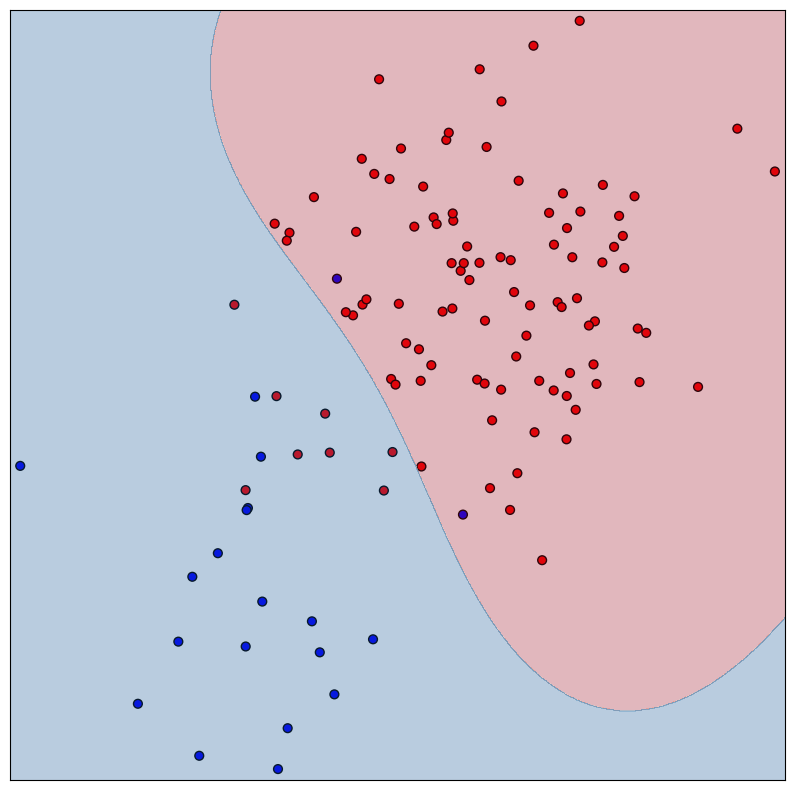

In [9]:
# Модель с дефолтными параметрами, которую Вам предстоит улучшить
base_model = SVC()
base_model.fit(X_distr1, y_distr1)
plot_separating_surface(X_distr2, y_distr2, base_model)

-----------
<font color="white" style="opacity:0.2025"></font>

Так как синих объектов было существенно больше в обучении, разделяющая поверхность отнесла к этому классу большую часть пространства около границы классов. При этом, из-за возросшего количества красных объектов в тестовой выборке, многие из них стали ошибочно относиться к другому классу.

Один из способов исправить эту проблему - это повлиять на форму поверхности с помощью задания весов классов, которые задаются через параметр class_weight в sklearn.svm.SVC. Особенно это может быть полезно в задачах, где известно, что распределение классов в обучающей выборке отличается от реального.
    


## <font color='DarkOrange'>**Задание 1 [2 баллa]**</font>

В данном задании вам будет дана выборка с несбалансированными данными. Кроме того, дана вторая выборка,
в которой классы имеют то же распределение, но классы имеют другое соотношение.  **Вам нужно построить различные rbf-модели, меняя параметры весов классов и визуализировать разделяющие поверхности. Попробуйте улучшить
качество на второй выборке (X_distr2, y_distr2), обучаясь только на первой (X_distr1, y_distr1) меняя параметры весов классов относительно дефолтных: class_weight={1: 1.0, 0: 1.0}. В качестве метрики, которую нужно оптимизировать нужно использовать accuracy на (X_distr2, y_dist2).**

In [10]:
from itertools import product

In [11]:
w1_best, w2_best = None, None
best_acc = None
grid = [0.01, 0.1, 0.5, 1.0, 5, 10, 100, 1000]
for w1, w2 in product(grid, grid):
    svc_cls = SVC(C=1.0, class_weight={1: w1, 0: w2})
    svc_cls.fit(X_distr1, y_distr1)
    acc = accuracy_score(y_distr2, svc_cls.predict(X_distr2))
    # Save model with best accuracy
    if best_acc is None or acc > best_acc:
        best_acc = acc
        w1_best, w2_best = w1, w2


print(f'Weight1: {w1_best},\nWeight2: {w2_best},\nBest accuracy: {best_acc}')

Weight1: 0.1,
Weight2: 5,
Best accuracy: 0.9666666666666667


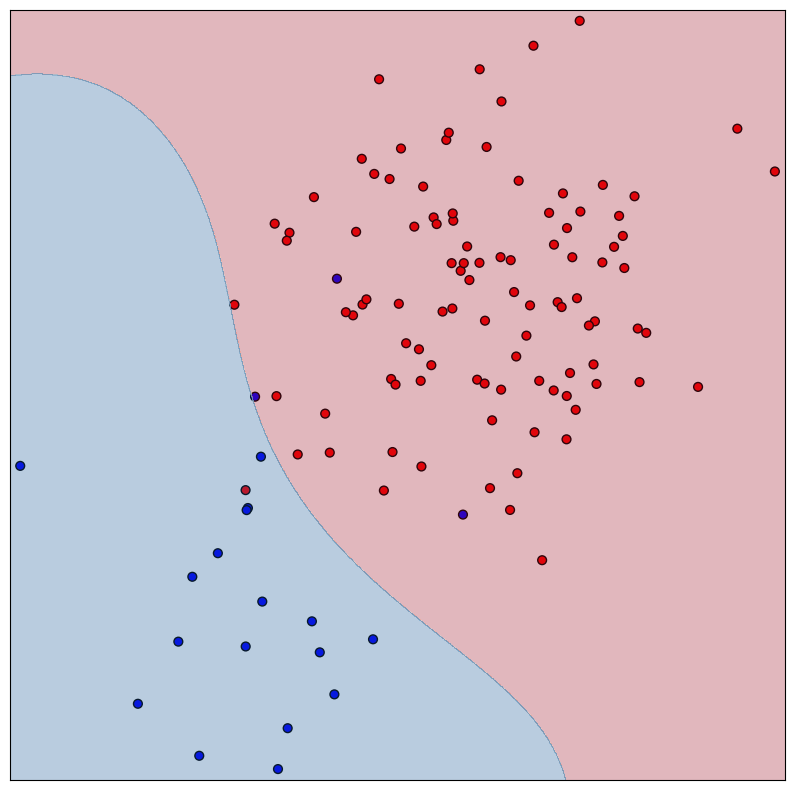

In [12]:
# best_svc_cls = ...
# Your code here

best_svc_cls = SVC(C=1.0, class_weight={1: w1_best, 0: w2_best})
best_svc_cls.fit(X_distr1, y_distr1)
plot_separating_surface(X_distr2, y_distr2, best_svc_cls)

In [13]:
print('My best classifier:')
print('Accuracy:', accuracy_score(y_distr2, best_svc_cls.predict(X_distr2)))

My best classifier:
Accuracy: 0.9666666666666667


# Ограничения SVM

В предыдущих заданиях мы убедились в мощности и гибкости моделей SVM. Теперь ответим на вопрос, насколько реально обучить модель SVM на выборках большого размера или с большим числом признаков.    Нужно провести два эксперимента.

## <font color='DarkOrange'>**Задание 2 [2 баллa]**</font>
    
В первом перебирать размер выборки
    и для каждого запуска посчитать реальное время обучения модели. При этом
    делить выборку на обучение и тестирование не нужно. Также качество обученной модели в данном эксперименте не имеет значение. Размеры выборки предлагается перебирать в диапазоне range(1000, 10001, 1000) с использованием generate_data_with_balanced_classes(size=n).
    
   Необходимо сравнить время обучения SVM с логистической регрессией. Для этого
    замеры повторите также для модели sklearn.linear_model.LogisticRegression. Время обучения одной модели замеряйте
    с помощью стандартной библиотеки time (пример в ячейке ниже).
    
Вы можете поставить эксперименты и с большими выборками, чем предлагается в задании (сгенерировать их),  
тогда эффект должен быть виден еще сильнее.

<font color='OrangeRed'>**Внимание!**</font> во время замеров времени работы, отключите сторонние процессы, занимающие CPU, иначе замеры времени работы окажутся некорректными. Помните, что времени работы в зависимости от числа данных и признаков должно меняться монотонно, без ступенчатых изменений (за исключением небольшого шума).

In [14]:
# Как замерять время
import time
time_start = time.time()
time.sleep(1) # Вместо этой команды - запуск замеряемого алгоритма
print("Время работы:", time.time() - time_start)

Время работы: 1.0002646446228027


In [15]:
def generate_data_with_balanced_classes(size=500, d=2, noise_scale=0.1):
    X = np.random.normal(size=(size*2, d))
    mask = X[:, 1] ** 2 > X[:, 0] - 0.1 + np.random.normal(scale=noise_scale)
    y = np.ones(len(X))
    y[mask] = 0
    return X, y

In [16]:
from time import perf_counter
from sklearn.linear_model import LinearRegression

In [17]:
results_time = []

for size in range(10**3, 10**5 + 1, 10**3):
    X, y = generate_data_with_balanced_classes(size)
    svc = SVC()
    lr = LinearRegression()
    start = perf_counter()
    lr.fit(X, y)
    end = perf_counter()
    delta_lr = end - start
    start = perf_counter()
    svc.fit(X, y)
    end = perf_counter()
    delta_svc = end - start
    results_time.append((delta_svc, delta_lr))
    print(f'Size {size}, {delta_svc = :4f}, {delta_lr = :4f}')

Size 1000, delta_svc = 0.016756, delta_lr = 0.001551
Size 2000, delta_svc = 0.038583, delta_lr = 0.001093
Size 3000, delta_svc = 0.091155, delta_lr = 0.001402
Size 4000, delta_svc = 0.134130, delta_lr = 0.001329
Size 5000, delta_svc = 0.204014, delta_lr = 0.002046
Size 6000, delta_svc = 0.301489, delta_lr = 0.001929
Size 7000, delta_svc = 0.375585, delta_lr = 0.001650
Size 8000, delta_svc = 0.445921, delta_lr = 0.001759
Size 9000, delta_svc = 0.529799, delta_lr = 0.001933
Size 10000, delta_svc = 0.638093, delta_lr = 0.001980
Size 11000, delta_svc = 0.795628, delta_lr = 0.002691
Size 12000, delta_svc = 0.802399, delta_lr = 0.003014
Size 13000, delta_svc = 1.010328, delta_lr = 0.002315
Size 14000, delta_svc = 1.211099, delta_lr = 0.002382
Size 15000, delta_svc = 1.270460, delta_lr = 0.002740
Size 16000, delta_svc = 1.292922, delta_lr = 0.002831
Size 17000, delta_svc = 1.632273, delta_lr = 0.002842
Size 18000, delta_svc = 1.505166, delta_lr = 0.003563
Size 19000, delta_svc = 1.851155, del

In [18]:
sizes = list(range(10**3, 10**5 + 1, 10**3))

In [19]:
results_by_time_df = pd.DataFrame([(x, y, z) for (x, y), z in zip(results_time, sizes)], columns=['svc_delta', 'lr_delta', 'size'])
results_by_time_df

,svc_delta,lr_delta,size
0,0.016756,0.001551,1000
1,0.038583,0.001093,2000
2,0.091155,0.001402,3000
3,0.134130,0.001329,4000
4,0.204014,0.002046,5000
...,...,...,...
95,29.357923,0.014674,96000
96,31.476619,0.014859,97000
97,32.517944,0.015110,98000
98,33.649782,0.014516,99000


In [20]:
results_by_time_df.describe()

,svc_delta,lr_delta,size
count,100.000000,100.000000,100.000000
mean,19.392673,0.007659,50500.000000
std,21.896824,0.003960,29011.491976
min,0.016756,0.001093,1000.000000
25%,3.183580,0.004431,25750.000000
50%,11.827321,0.007470,50500.000000
75%,27.943119,0.010205,75250.000000
max,87.489530,0.017857,100000.000000


In [21]:
import seaborn as sns
sns.set_palette("husl")

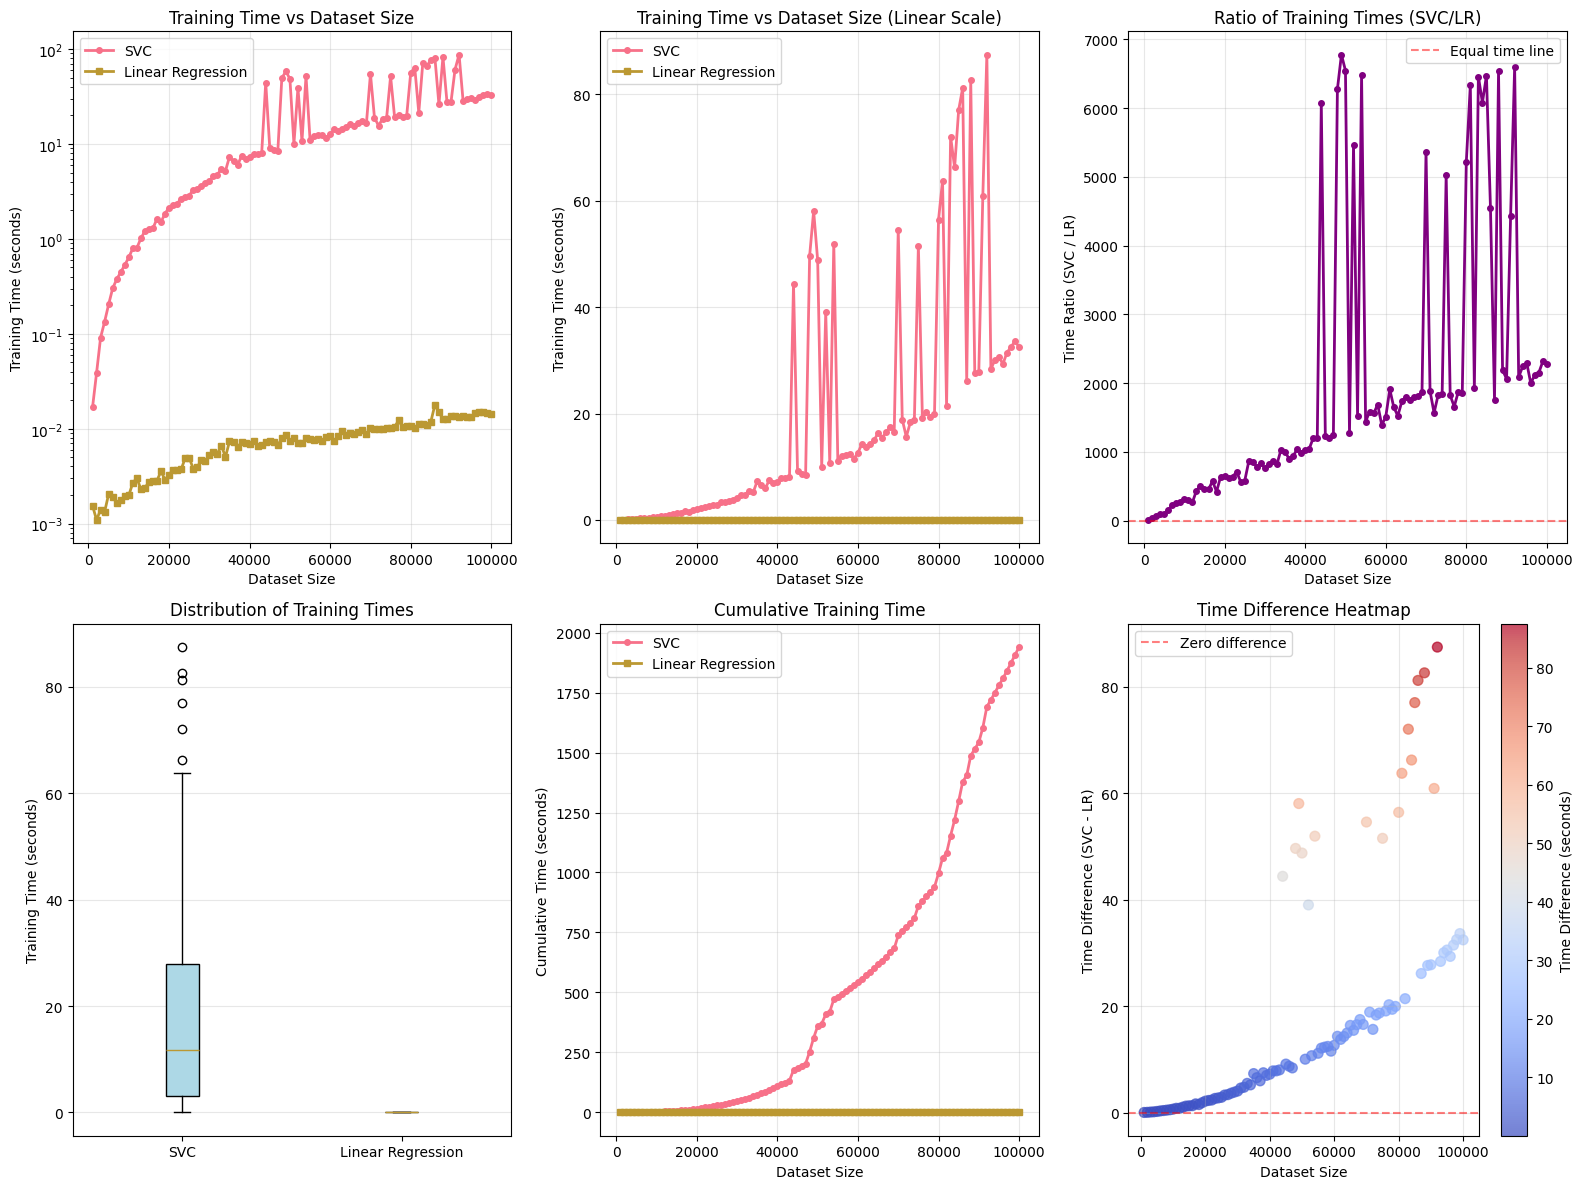

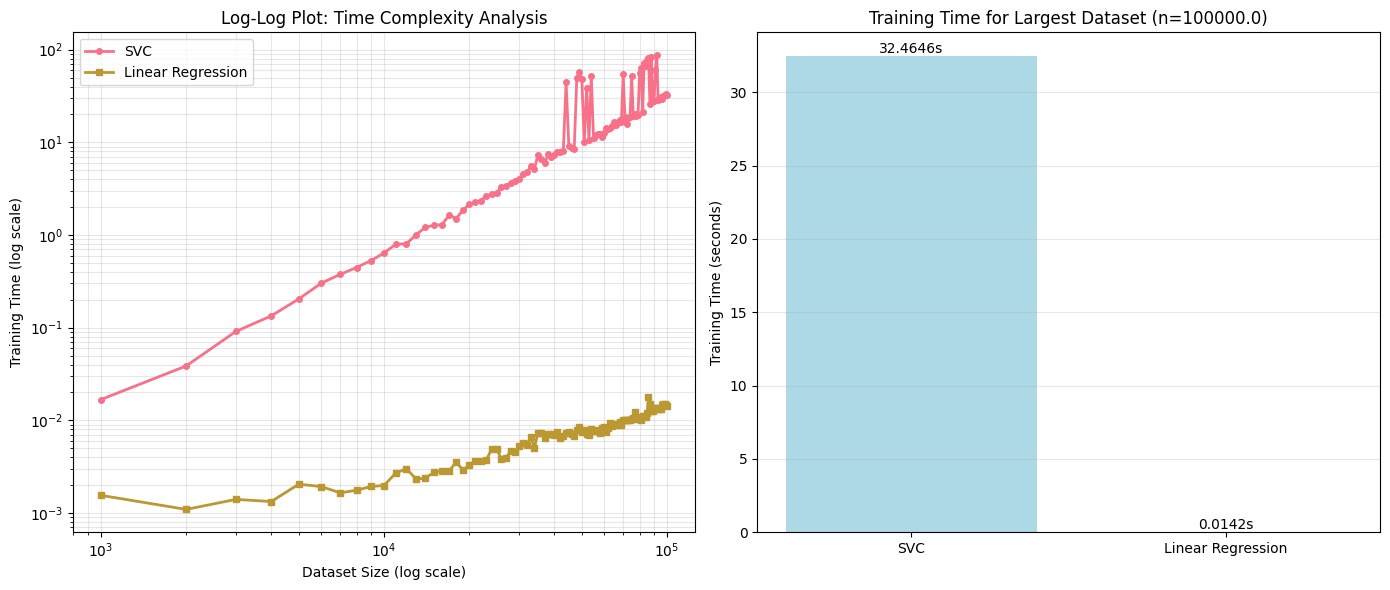

In [22]:
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 3, 1)
ax1.plot(results_by_time_df['size'], results_by_time_df['svc_delta'], 'o-', label='SVC', linewidth=2, markersize=4)
ax1.plot(results_by_time_df['size'], results_by_time_df['lr_delta'], 's-', label='Linear Regression', linewidth=2, markersize=4)
ax1.set_xlabel('Dataset Size')
ax1.set_ylabel('Training Time (seconds)')
ax1.set_title('Training Time vs Dataset Size')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 3, 2)
ax2.plot(results_by_time_df['size'], results_by_time_df['svc_delta'], 'o-', label='SVC', linewidth=2, markersize=4)
ax2.plot(results_by_time_df['size'], results_by_time_df['lr_delta'], 's-', label='Linear Regression', linewidth=2, markersize=4)
ax2.set_xlabel('Dataset Size')
ax2.set_ylabel('Training Time (seconds)')
ax2.set_title('Training Time vs Dataset Size (Linear Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

results_by_time_df['time_ratio'] = results_by_time_df['svc_delta'] / results_by_time_df['lr_delta']
ax3 = plt.subplot(2, 3, 3)
ax3.plot(results_by_time_df['size'], results_by_time_df['time_ratio'], 'o-', color='purple', linewidth=2, markersize=4)
ax3.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Equal time line')
ax3.set_xlabel('Dataset Size')
ax3.set_ylabel('Time Ratio (SVC / LR)')
ax3.set_title('Ratio of Training Times (SVC/LR)')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(2, 3, 4)
box_data = [results_by_time_df['svc_delta'], results_by_time_df['lr_delta']]
bp = ax4.boxplot(box_data, tick_labels=['SVC', 'Linear Regression'], patch_artist=True)
colors = ['lightblue', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax4.set_ylabel('Training Time (seconds)')
ax4.set_title('Distribution of Training Times')
ax4.grid(True, alpha=0.3, axis='y')

results_by_time_df['svc_cumulative'] = results_by_time_df['svc_delta'].cumsum()
results_by_time_df['lr_cumulative'] = results_by_time_df['lr_delta'].cumsum()
ax5 = plt.subplot(2, 3, 5)
ax5.plot(results_by_time_df['size'], results_by_time_df['svc_cumulative'], 'o-', label='SVC', linewidth=2, markersize=4)
ax5.plot(results_by_time_df['size'], results_by_time_df['lr_cumulative'], 's-', label='Linear Regression', linewidth=2, markersize=4)
ax5.set_xlabel('Dataset Size')
ax5.set_ylabel('Cumulative Time (seconds)')
ax5.set_title('Cumulative Training Time')
ax5.legend()
ax5.grid(True, alpha=0.3)

results_by_time_df['time_diff'] = results_by_time_df['svc_delta'] - results_by_time_df['lr_delta']
ax6 = plt.subplot(2, 3, 6)
scatter = ax6.scatter(results_by_time_df['size'], results_by_time_df['time_diff'], 
                      c=results_by_time_df['time_diff'], cmap='coolwarm', 
                      s=50, alpha=0.7)
ax6.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Zero difference')
ax6.set_xlabel('Dataset Size')
ax6.set_ylabel('Time Difference (SVC - LR)')
ax6.set_title('Time Difference Heatmap')
plt.colorbar(scatter, ax=ax6, label='Time Difference (seconds)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.loglog(results_by_time_df['size'], results_by_time_df['svc_delta'], 'o-', label='SVC', linewidth=2, markersize=4)
ax1.loglog(results_by_time_df['size'], results_by_time_df['lr_delta'], 's-', label='Linear Regression', linewidth=2, markersize=4)
ax1.set_xlabel('Dataset Size (log scale)')
ax1.set_ylabel('Training Time (log scale)')
ax1.set_title('Log-Log Plot: Time Complexity Analysis')
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')

last_row = results_by_time_df.iloc[-1]
models = ['SVC', 'Linear Regression']
times = [last_row['svc_delta'], last_row['lr_delta']]
bars = ax2.bar(models, times, color=['lightblue', 'lightgreen'])
ax2.set_ylabel('Training Time (seconds)')
ax2.set_title(f'Training Time for Largest Dataset (n={last_row["size"]})')
ax2.grid(True, alpha=0.3, axis='y')

for bar, time in zip(bars, times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{time:.4f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## <font color='DarkOrange'>**Задание 3 [2 баллa]**</font>

Во втором эксперименте предлагается проделать то же самое, что и в первом эксперименте, только меняя размерность пространства признаков.
    Для этого можете воспользоваться функцией generate_data_with_balanced_classes(dim=d). Признаки предлагается перебирать по сетке `range(10, 1001, 100)`.

Постройте графики времени работы в зависимости от числа признаков для SVM и логистической регрессии, сравните их и сделайте выводы.
    
<font color='LightSteelBlue'>**Подсказка**</font> Придумывая обоснование получившимся результатам попробуйте использовать
    вид решаемой задачи в SVM, который был дан вам на лекции.

In [23]:
results_dim = []

for dim in range(10, 10**4 + 1, 100):
    X, y = generate_data_with_balanced_classes(d=dim)
    svc = SVC()
    lr = LinearRegression()
    start = perf_counter()
    lr.fit(X, y)
    end = perf_counter()
    delta_lr = end - start
    start = perf_counter()
    svc.fit(X, y)
    end = perf_counter()
    delta_svc = end - start
    results_dim.append((delta_svc, delta_lr, dim))
    print(f'{dim = }, {delta_svc = :4f}, {delta_lr = :4f}')

dim = 10, delta_svc = 0.020686, delta_lr = 0.001898
dim = 110, delta_svc = 0.153913, delta_lr = 0.252471
dim = 210, delta_svc = 0.180361, delta_lr = 0.028706
dim = 310, delta_svc = 0.187067, delta_lr = 0.050279
dim = 410, delta_svc = 0.224707, delta_lr = 0.103990
dim = 510, delta_svc = 0.265037, delta_lr = 0.136187
dim = 610, delta_svc = 0.282929, delta_lr = 0.181167
dim = 710, delta_svc = 0.336163, delta_lr = 0.249171
dim = 810, delta_svc = 0.376115, delta_lr = 0.299601
dim = 910, delta_svc = 0.444072, delta_lr = 0.356620
dim = 1010, delta_svc = 0.479138, delta_lr = 0.416267
dim = 1110, delta_svc = 0.583082, delta_lr = 0.442353
dim = 1210, delta_svc = 0.625716, delta_lr = 0.548591
dim = 1310, delta_svc = 0.746001, delta_lr = 0.617361
dim = 1410, delta_svc = 0.763527, delta_lr = 0.687414
dim = 1510, delta_svc = 0.894384, delta_lr = 0.795081
dim = 1610, delta_svc = 0.897540, delta_lr = 0.663822
dim = 1710, delta_svc = 1.006728, delta_lr = 0.929367
dim = 1810, delta_svc = 1.073132, delta

In [24]:
results_by_dim_df = pd.DataFrame(results_dim, columns=['svc_delta', 'lr_delta', 'dim'])
results_by_dim_df

,svc_delta,lr_delta,dim
0,0.020686,0.001898,10
1,0.153913,0.252471,110
2,0.180361,0.028706,210
3,0.187067,0.050279,310
4,0.224707,0.103990,410
...,...,...,...
95,6.781986,2.181555,9510
96,6.891697,2.444432,9610
97,6.953168,2.183580,9710
98,7.043518,2.185135,9810


In [25]:
results_by_dim_df.describe()

,svc_delta,lr_delta,dim
count,100.000000,100.000000,100.000000
mean,3.458607,1.284595,4960.000000
std,2.135572,0.666948,2901.149198
min,0.020686,0.001898,10.000000
25%,1.540719,0.777093,2485.000000
50%,3.463488,1.259489,4960.000000
75%,5.226670,1.828478,7435.000000
max,7.095753,2.577842,9910.000000


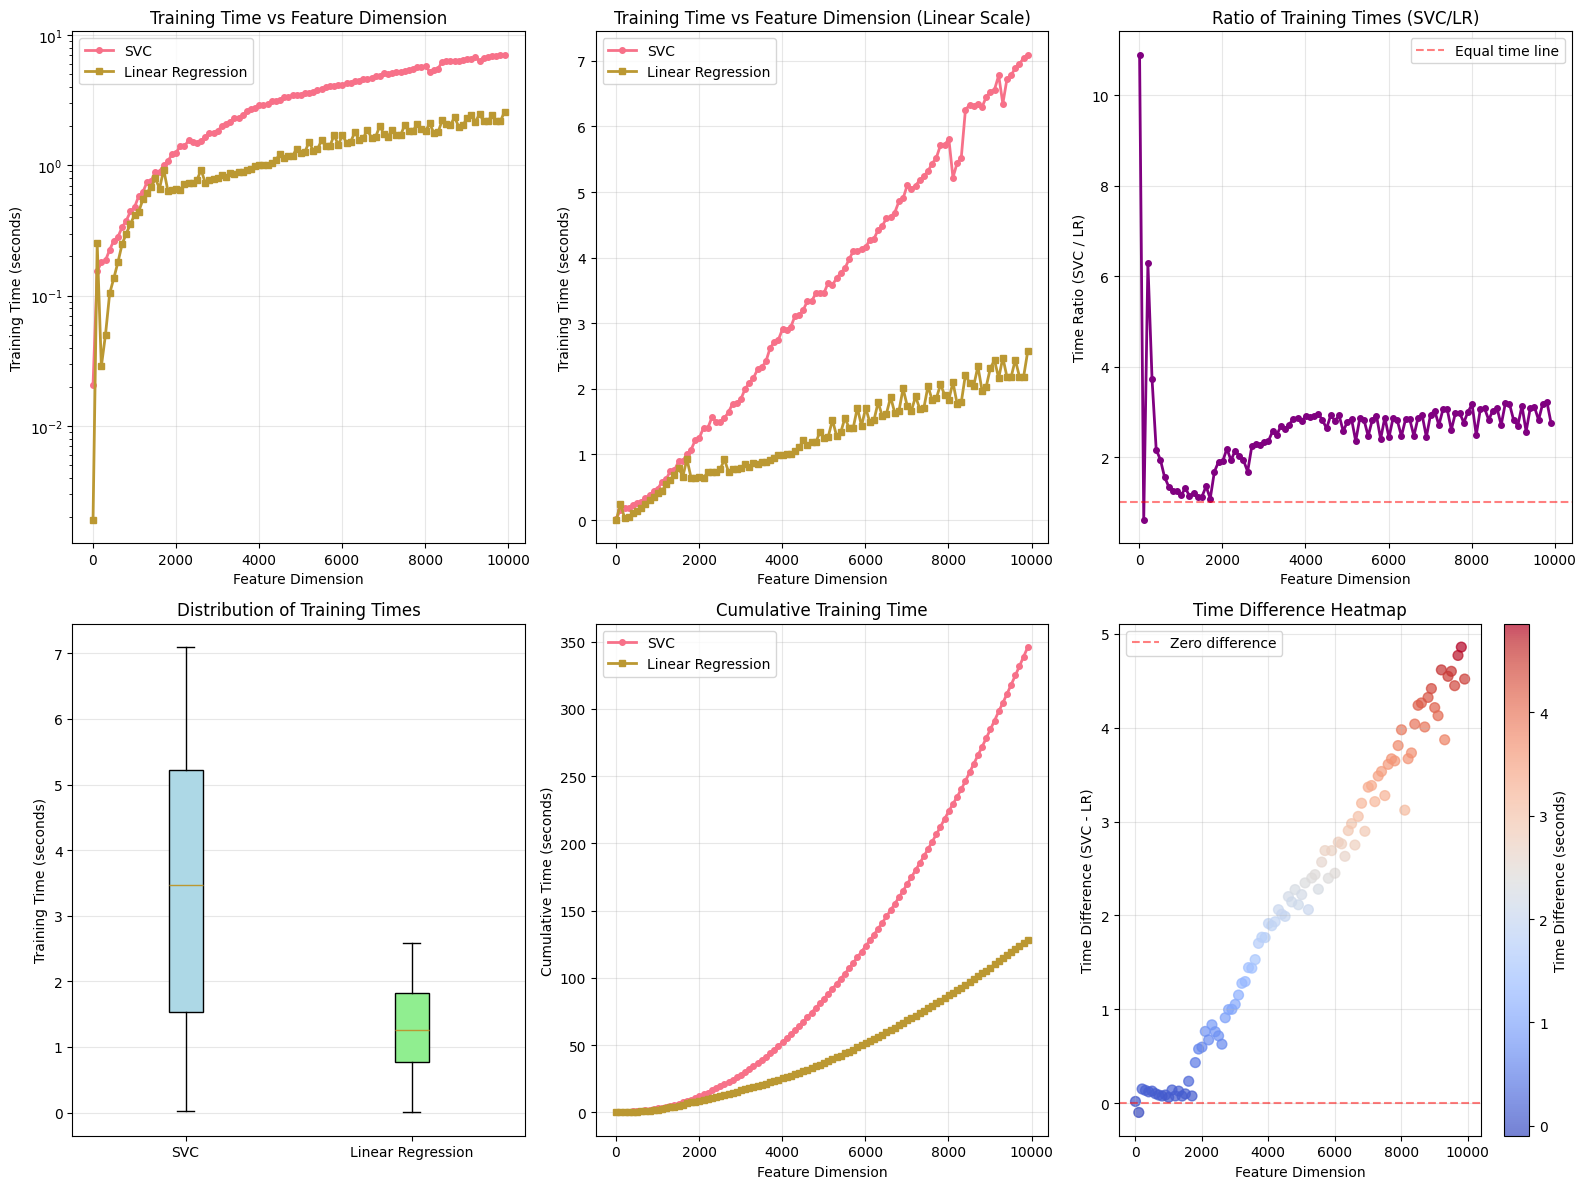

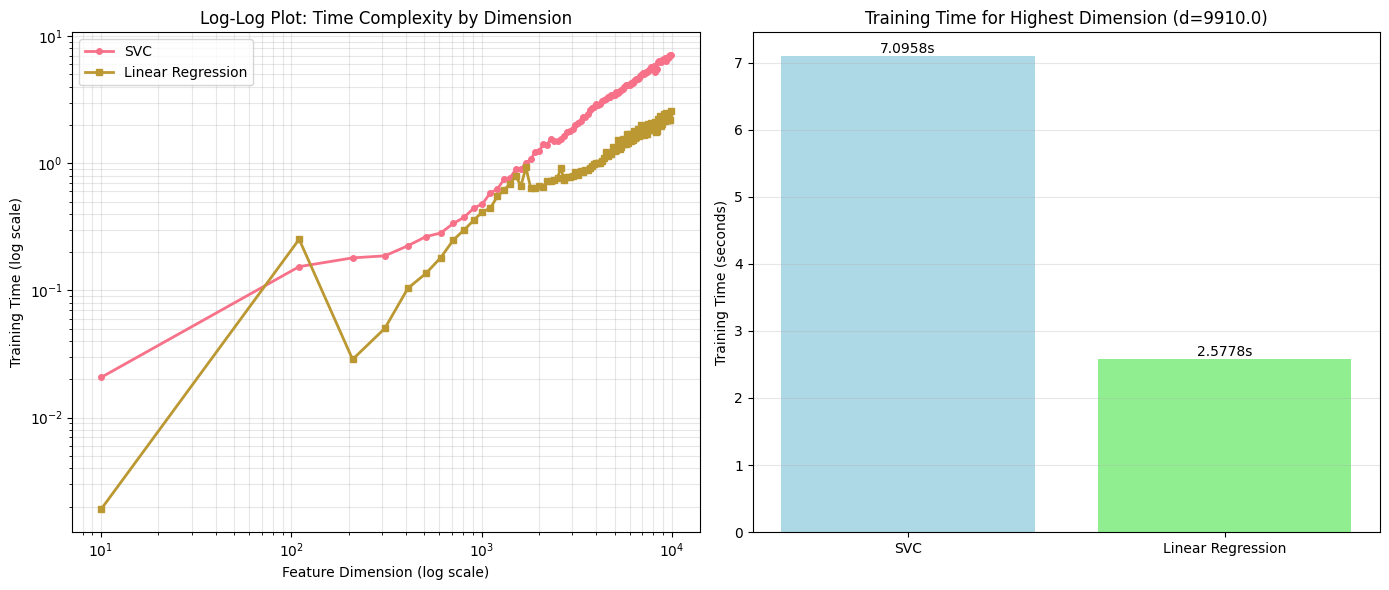

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 3, 1)
ax1.plot(results_by_dim_df['dim'], results_by_dim_df['svc_delta'], 'o-', label='SVC', linewidth=2, markersize=4)
ax1.plot(results_by_dim_df['dim'], results_by_dim_df['lr_delta'], 's-', label='Linear Regression', linewidth=2, markersize=4)
ax1.set_xlabel('Feature Dimension')
ax1.set_ylabel('Training Time (seconds)')
ax1.set_title('Training Time vs Feature Dimension')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 3, 2)
ax2.plot(results_by_dim_df['dim'], results_by_dim_df['svc_delta'], 'o-', label='SVC', linewidth=2, markersize=4)
ax2.plot(results_by_dim_df['dim'], results_by_dim_df['lr_delta'], 's-', label='Linear Regression', linewidth=2, markersize=4)
ax2.set_xlabel('Feature Dimension')
ax2.set_ylabel('Training Time (seconds)')
ax2.set_title('Training Time vs Feature Dimension (Linear Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

results_by_dim_df['time_ratio'] = results_by_dim_df['svc_delta'] / results_by_dim_df['lr_delta']
ax3 = plt.subplot(2, 3, 3)
ax3.plot(results_by_dim_df['dim'], results_by_dim_df['time_ratio'], 'o-', color='purple', linewidth=2, markersize=4)
ax3.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Equal time line')
ax3.set_xlabel('Feature Dimension')
ax3.set_ylabel('Time Ratio (SVC / LR)')
ax3.set_title('Ratio of Training Times (SVC/LR)')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(2, 3, 4)
box_data = [results_by_dim_df['svc_delta'], results_by_dim_df['lr_delta']]
bp = ax4.boxplot(box_data, tick_labels=['SVC', 'Linear Regression'], patch_artist=True)
colors = ['lightblue', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax4.set_ylabel('Training Time (seconds)')
ax4.set_title('Distribution of Training Times')
ax4.grid(True, alpha=0.3, axis='y')

results_by_dim_df['svc_cumulative'] = results_by_dim_df['svc_delta'].cumsum()
results_by_dim_df['lr_cumulative'] = results_by_dim_df['lr_delta'].cumsum()
ax5 = plt.subplot(2, 3, 5)
ax5.plot(results_by_dim_df['dim'], results_by_dim_df['svc_cumulative'], 'o-', label='SVC', linewidth=2, markersize=4)
ax5.plot(results_by_dim_df['dim'], results_by_dim_df['lr_cumulative'], 's-', label='Linear Regression', linewidth=2, markersize=4)
ax5.set_xlabel('Feature Dimension')
ax5.set_ylabel('Cumulative Time (seconds)')
ax5.set_title('Cumulative Training Time')
ax5.legend()
ax5.grid(True, alpha=0.3)

results_by_dim_df['time_diff'] = results_by_dim_df['svc_delta'] - results_by_dim_df['lr_delta']
ax6 = plt.subplot(2, 3, 6)
scatter = ax6.scatter(results_by_dim_df['dim'], results_by_dim_df['time_diff'], 
                      c=results_by_dim_df['time_diff'], cmap='coolwarm', 
                      s=50, alpha=0.7)
ax6.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Zero difference')
ax6.set_xlabel('Feature Dimension')
ax6.set_ylabel('Time Difference (SVC - LR)')
ax6.set_title('Time Difference Heatmap')
plt.colorbar(scatter, ax=ax6, label='Time Difference (seconds)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.loglog(results_by_dim_df['dim'], results_by_dim_df['svc_delta'], 'o-', label='SVC', linewidth=2, markersize=4)
ax1.loglog(results_by_dim_df['dim'], results_by_dim_df['lr_delta'], 's-', label='Linear Regression', linewidth=2, markersize=4)
ax1.set_xlabel('Feature Dimension (log scale)')
ax1.set_ylabel('Training Time (log scale)')
ax1.set_title('Log-Log Plot: Time Complexity by Dimension')
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')

last_row = results_by_dim_df.iloc[-1]
models = ['SVC', 'Linear Regression']
times = [last_row['svc_delta'], last_row['lr_delta']]
bars = ax2.bar(models, times, color=['lightblue', 'lightgreen'])
ax2.set_ylabel('Training Time (seconds)')
ax2.set_title(f'Training Time for Highest Dimension (d={last_row["dim"]})')
ax2.grid(True, alpha=0.3, axis='y')

for bar, time in zip(bars, times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{time:.4f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

При малой размерности признаков эдак до 1000, время выполнения алгоритмов сравнимо, ибо вычислительные затраты ещё не определяются операциями, линейно зависящими от размерности, &mdash; это объясняется тем, что SVM в своей канонической C-формулировке решает двойственную задачу квадратичного программирования, где центральное место занимает вычисление матрицы ядра, каждый элемент которой для в нашем случае RBF-ядра определяется как $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$, причём вычисление евклидовой нормы требует $O(d)$ операций суммирования квадратов разностей по всем признакам

В области средних размерностей от 1000 до 5000 признаков SVM начинает устойчиво проигрывать в скорости &mdash; этот эффект объясняется комбинацией двух факторов: необходимостью вычисления попарных расстояний между всеми объектами выборки, что даёт сложность $O(n^2 \cdot d)$, и решением задачи квадратичного программирования с ограничениями, которое в общем случае имеет кубическую сложность от числа объектов, тогда как логистическая регрессия оптимизирует логарифмическую функцию правдоподобия $\log(1 + \exp(-y_i w^T x_i))$ с помощью итеративных методов типа IRLS или градиентного спуска, где основная операция &mdash; вычисление скалярных произведений $w^T x_i$ с линейной сложностью $O(d)$ на объект

Логистическая регрессия демонстрирует неравномерную динамику времени обучения с заметными скачками &mdash; ибо я скорее всего пользовался чем-то помимо, да и методы оптиизации могли нашаманить из-за данных случайных, мб неудачное начальное приближение или типа того, в IRLS например сходимость сильно зависит от числа обусловленности матрицы $X^T W X$, которое резко меняется с ростом размерности, увеличивая количество итераций

При высокой размерности более 5000 признаков разрыв в производительности становится выраженным &mdash; SVM с ядром требует явного вычисления и хранения матрицы ядра размера $n \times n$, что создаёт квадратичные требования к памяти и вычислениям, тогда как логистическая регрессия обходится хранением только вектора весов размерности $d$ и использует стохастические или пакетные градиентные методы, эффективно работающие даже в сверхвысокомерных пространствах

Ну короче, хоть SVM с ядром и гибче, но считать это кнчн треееш, ибо квадратичный рост с размером выборки и линейный с размерностью пространства совсем не оч, поэтому он не победил нейронки, а ещё удачи это распараллелить

Суммарно, и там, и там по размерности пространства линейный рост, но у SVM коэффициент побольше, чем у логистической

Что же касаемо среднего, довольно быстро оно поднялось с в целом плохо скора до средненького и особо не колебалось, ну вот наверное точку стабилизации по количеству компонент и стоит взять за оптимум

# Уменьшение размерности входа

Если уменьшение числа объектов сложная и зачастую невозможная задача, то
    для понижения числа признаков существует стандартное решение. В предыдущих заданиях Вы уже сталкивались с l1-регуляризацией, которая позволяла уменьшить число признаков в задаче линейной классификации/регрессии. Однако для большинства ML-алгоритмов такой способ уменьшения числа признаков неприменим.
    
   Зато существует стандартное для всех алгоритмов понижение размерности входа. Данный алгоритм называется Principal Component Analysis (PCA, метод главных компонент). Он находит такое линейное пространство меньшей размерности $k$ ($k << d$, где d изначальная размерность входа), проекция на которое теряет меньше всего информации. Подробнее об этом можете почитать тут https://scikit-learn.org/stable/modules/decomposition.html#pca.

## <font color='DarkOrange'>**Задание 4 [2 баллa]**</font>


    
   **Эксперимент:** Проекция в очень малое число координат сильно "упрощает" выборку, из-за чего качество решения задачи может в итоге упасть. **В следующем эксперименте предлагается исследовать зависимость скорости работы метода и качества решения задачи при использовании понижения размерности. Требуется построить два графика:**

1. График зависимости времени работы всего цикла обучения от числа признаков $k$, которое остается после применения PCA.
2. График зависимости качества решения (accuracy) задачи классификации от числа признаков $k$, которое остается после применения PCA.
    
При этом под полным циклом обучения подразумевается обучение PCA + обучение SVM. Данные для обучения: первые две координаты - "луны", а остальные координаты, случайные.
Таким образом, без понижения размерности SVM с rbf ядром должен иметь точность близкую к 100\%. Чтобы лучше
видеть эффект на графиках, можете менять размер генерируемой выборки. Для данных размеров $k$ рекомендуется перебирать от 10 до 500 (тогда будет видна требуемая закономерность).
    
<font color='OrangeRed'>**Обратите внимание!**</font> Не забывайте делить выборку на обучение и валидацию в этом эксперименте (так как мы смотрим на качество, мы хотим считать его честно). При этом PCA как и любой другой алгоритм ML тоже нельзя учить на тесте. Общая схема применения PCA описана в ячейках ниже.

In [59]:
X_moons, y_moons = make_moons_cls(2000, 1000)

In [60]:
X_moons.shape

(2000, 1000)

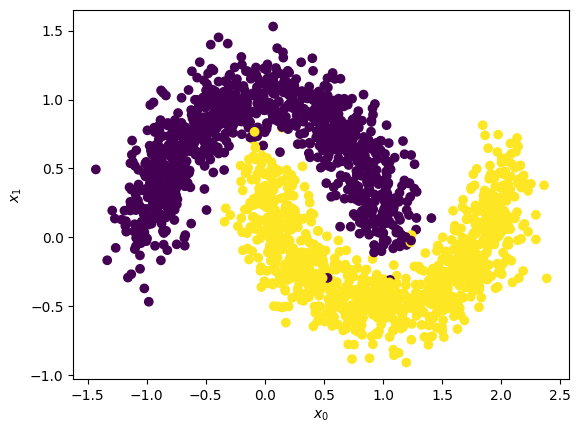

In [61]:
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons)
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.show()

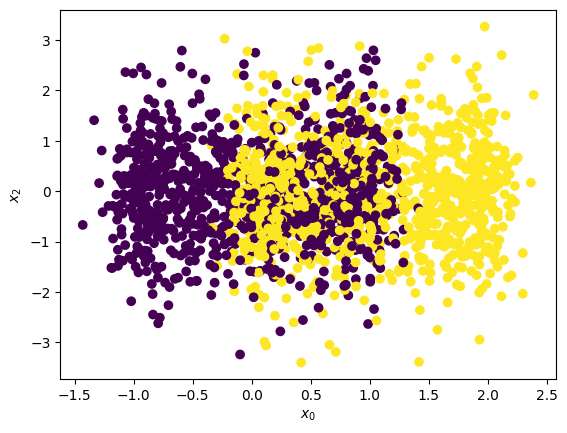

In [62]:
plt.scatter(X_moons[:, 0], X_moons[:, 2], c=y_moons)
plt.xlabel('$x_0$')
plt.ylabel('$x_2$')
plt.show()

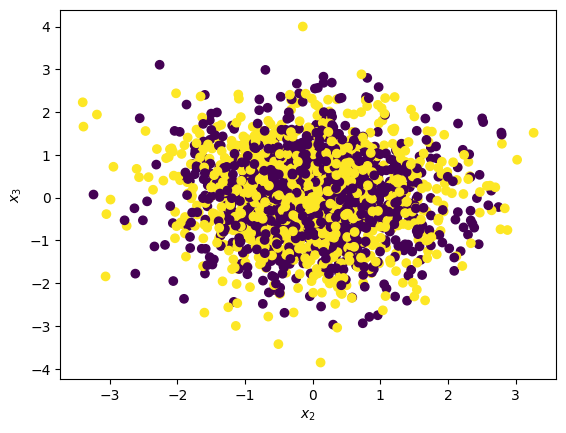

In [63]:
plt.scatter(X_moons[:, 2], X_moons[:, 3], c=y_moons)
plt.xlabel('$x_2$')
plt.ylabel('$x_3$')
plt.show()

Казалось бы понизить размерность в этой задаче достаточно легко, нужно просто выбрать только первые две координаты. Однако из-за нелинейности разделяющей поверхности, для PCA это задача нетривиальна. Такая же ситуация наблюдается и в большинстве прикладных задач. Теперь переходите **к эксперименту** :)

In [82]:
# Пример правильного обучения PCA с делением на train/test
pca_model = PCA(n_components=500)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2) # делим выборку на трейн тест для оценки качества всего алгоритма

X_train_for_pca, X_train_for_svc, y_train_for_pca, y_train_for_svc = train_test_split(
    X_moons_train, y_moons_train, test_size=0.5) # делим выборку на трейн тест для оценки качества всего алгоритма

print(X_moons.shape, y_moons.shape)
print(X_moons_train.shape, y_moons_train.shape)
print(X_train_for_pca.shape, y_train_for_pca.shape)

# Учим PCA
pca_model.fit(X_train_for_pca)

# Применяем PCA
X_moons_test_transformed = pca_model.transform(X_moons_test)
X_train_for_svc_transformed = pca_model.transform(X_train_for_svc)

print(X_train_for_svc_transformed.shape)

# Учим SVC (на другой выборке чтобы не переобучиться)
svc_on_transformed = SVC(kernel='rbf')
svc_on_transformed.fit(X_train_for_svc_transformed, y_train_for_svc)

preds = svc_on_transformed.predict(X_moons_test_transformed)

print('Accuracy after PCA:', accuracy_score(preds, y_moons_test))

(2000, 1000) (2000,)
(1600, 1000) (1600,)
(800, 1000) (800,)
(800, 500)
Accuracy after PCA: 0.5875


In [73]:
import itertools

In [92]:
results_pca_svc = []

for size in range(10, 500, 10):
    X_experiment_moons, y_experiment_moons = make_moons_cls(size, 1000)
    X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
        X_experiment_moons, y_experiment_moons, test_size=0.2) # general accuracy
    X_train_for_pca, X_train_for_svc, y_train_for_pca, y_train_for_svc = train_test_split(
        X_moons_train, y_moons_train, test_size=0.5) # for train

    assert X_train_for_pca.shape[1] == X_train_for_svc.shape[1] == X_moons_train.shape[1] == X_experiment_moons.shape[1]

    for components_count in itertools.takewhile(lambda x: x <= X_train_for_pca.shape[1] and x <= X_train_for_pca.shape[0],
                                                itertools.chain(range(1, 100),
                                                                range(100, 500, 10),
                                                                range(500, X_experiment_moons.shape[1] + 1, 100))):
        pca_model = PCA(n_components=components_count)
        svc_on_transformed = SVC(kernel='rbf')
        start = perf_counter()
        pca_model.fit(X_train_for_pca)
        mid = perf_counter()
        X_moons_test_transformed = pca_model.transform(X_moons_test)
        X_train_for_svc_transformed = pca_model.transform(X_train_for_svc)
        transform = perf_counter()
        svc_on_transformed.fit(X_train_for_svc_transformed, y_train_for_svc)
        predict = perf_counter()
        preds = svc_on_transformed.predict(X_moons_test_transformed)
        end = perf_counter()
        score = accuracy_score(preds, y_moons_test)
        results_pca_svc.append((size, components_count, score, mid - start, transform - mid, predict - transform, end - predict))
        print((size, components_count, score, mid - start, transform - mid, predict - transform, end - predict))

(10, 1, 0.5, 0.001429638999979943, 0.0005635830020764843, 0.0021740859956480563, 0.0003373749932507053)
(10, 2, 0.5, 0.0010877419990720227, 0.0004824599891435355, 0.001081072012311779, 0.00023083799169398844)
(10, 3, 0.5, 0.001369587000226602, 0.0003742629924090579, 0.0009459240100113675, 0.00023373898875433952)
(10, 4, 0.5, 0.001264948004973121, 0.0006630989955738187, 0.0015904879983281717, 0.0005511130002560094)
(20, 1, 0.0, 0.001589702005730942, 0.000436818998423405, 0.0009092989930650219, 0.00025388499489054084)
(20, 2, 0.25, 0.0013797450083075091, 0.0004095530021004379, 0.0009124829957727343, 0.00027735400362871587)
(20, 3, 0.5, 0.002087603003019467, 0.000797379994764924, 0.0014398810017155483, 0.00037498900201171637)
(20, 4, 0.25, 0.003155780999804847, 0.00045787398994434625, 0.0009077320137294009, 0.00041473399323876947)
(20, 5, 0.25, 0.0016004990029614419, 0.00041656299435999244, 0.0009047700004884973, 0.0002683999919099733)
(20, 6, 0.25, 0.0014295760047389194, 0.00045006899745

In [94]:
results_pca_svc_df = pd.DataFrame(results_pca_svc, columns=['size', 'dim', 'accuracy', 'delta_pca_fit', 'delta_pca_transform', 'delta_svc_fit', 'delta_svc_predict'])
results_pca_svc_df

,size,dim,accuracy,delta_pca_fit,delta_pca_transform,delta_svc_fit,delta_svc_predict
0,10,1,0.500000,0.001430,0.000564,0.002174,0.000337
1,10,2,0.500000,0.001088,0.000482,0.001081,0.000231
2,10,3,0.500000,0.001370,0.000374,0.000946,0.000234
3,10,4,0.500000,0.001265,0.000663,0.001590,0.000551
4,20,1,0.000000,0.001590,0.000437,0.000909,0.000254
...,...,...,...,...,...,...,...
3805,490,150,0.500000,1.673537,0.079434,0.013314,0.015046
3806,490,160,0.489796,0.373568,0.099776,0.016131,0.029776
3807,490,170,0.459184,0.171234,0.071616,0.012304,0.019517
3808,490,180,0.479592,0.178656,0.078610,0.010927,0.019936


In [106]:
results_pca_svc_df['size'].unique()

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260,
       270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390,
       400, 410, 420, 430, 440, 450, 460, 470, 480, 490])

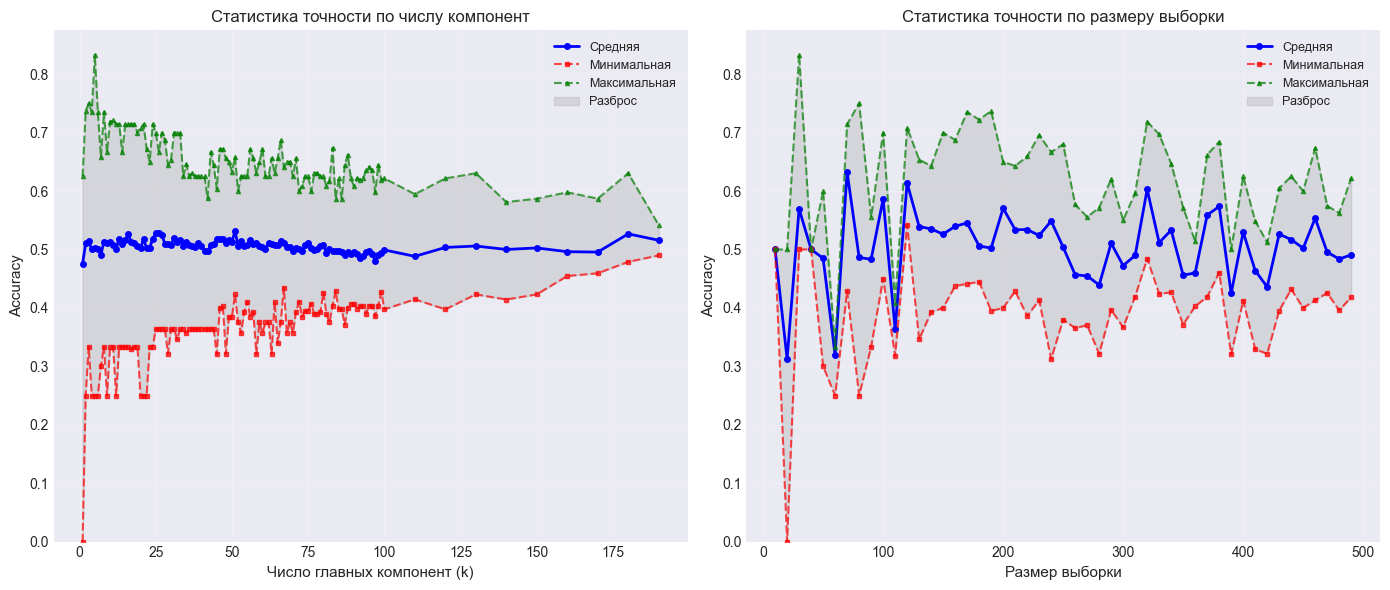

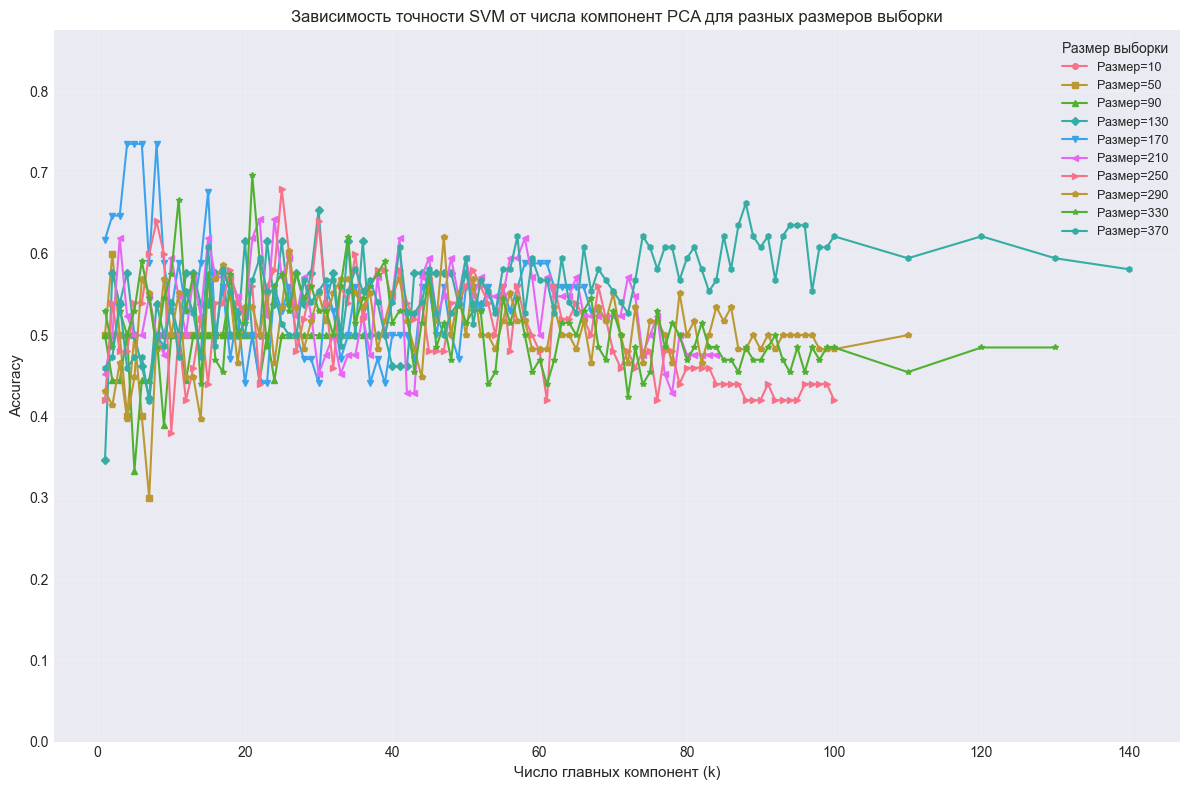

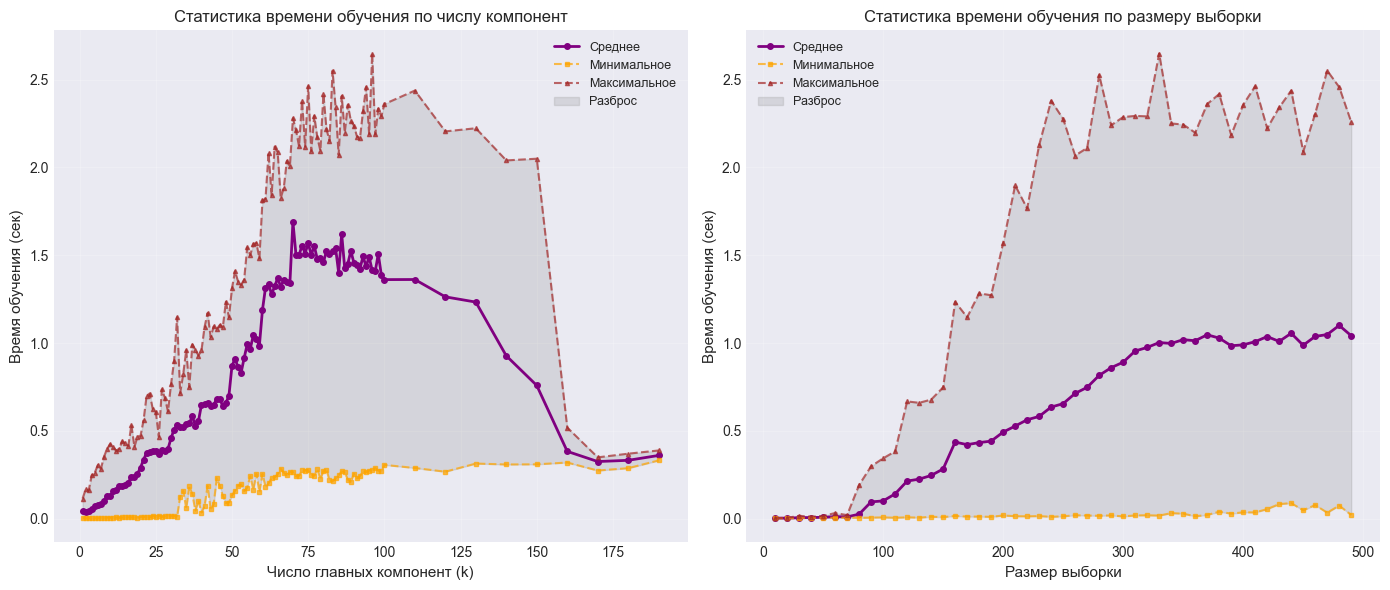

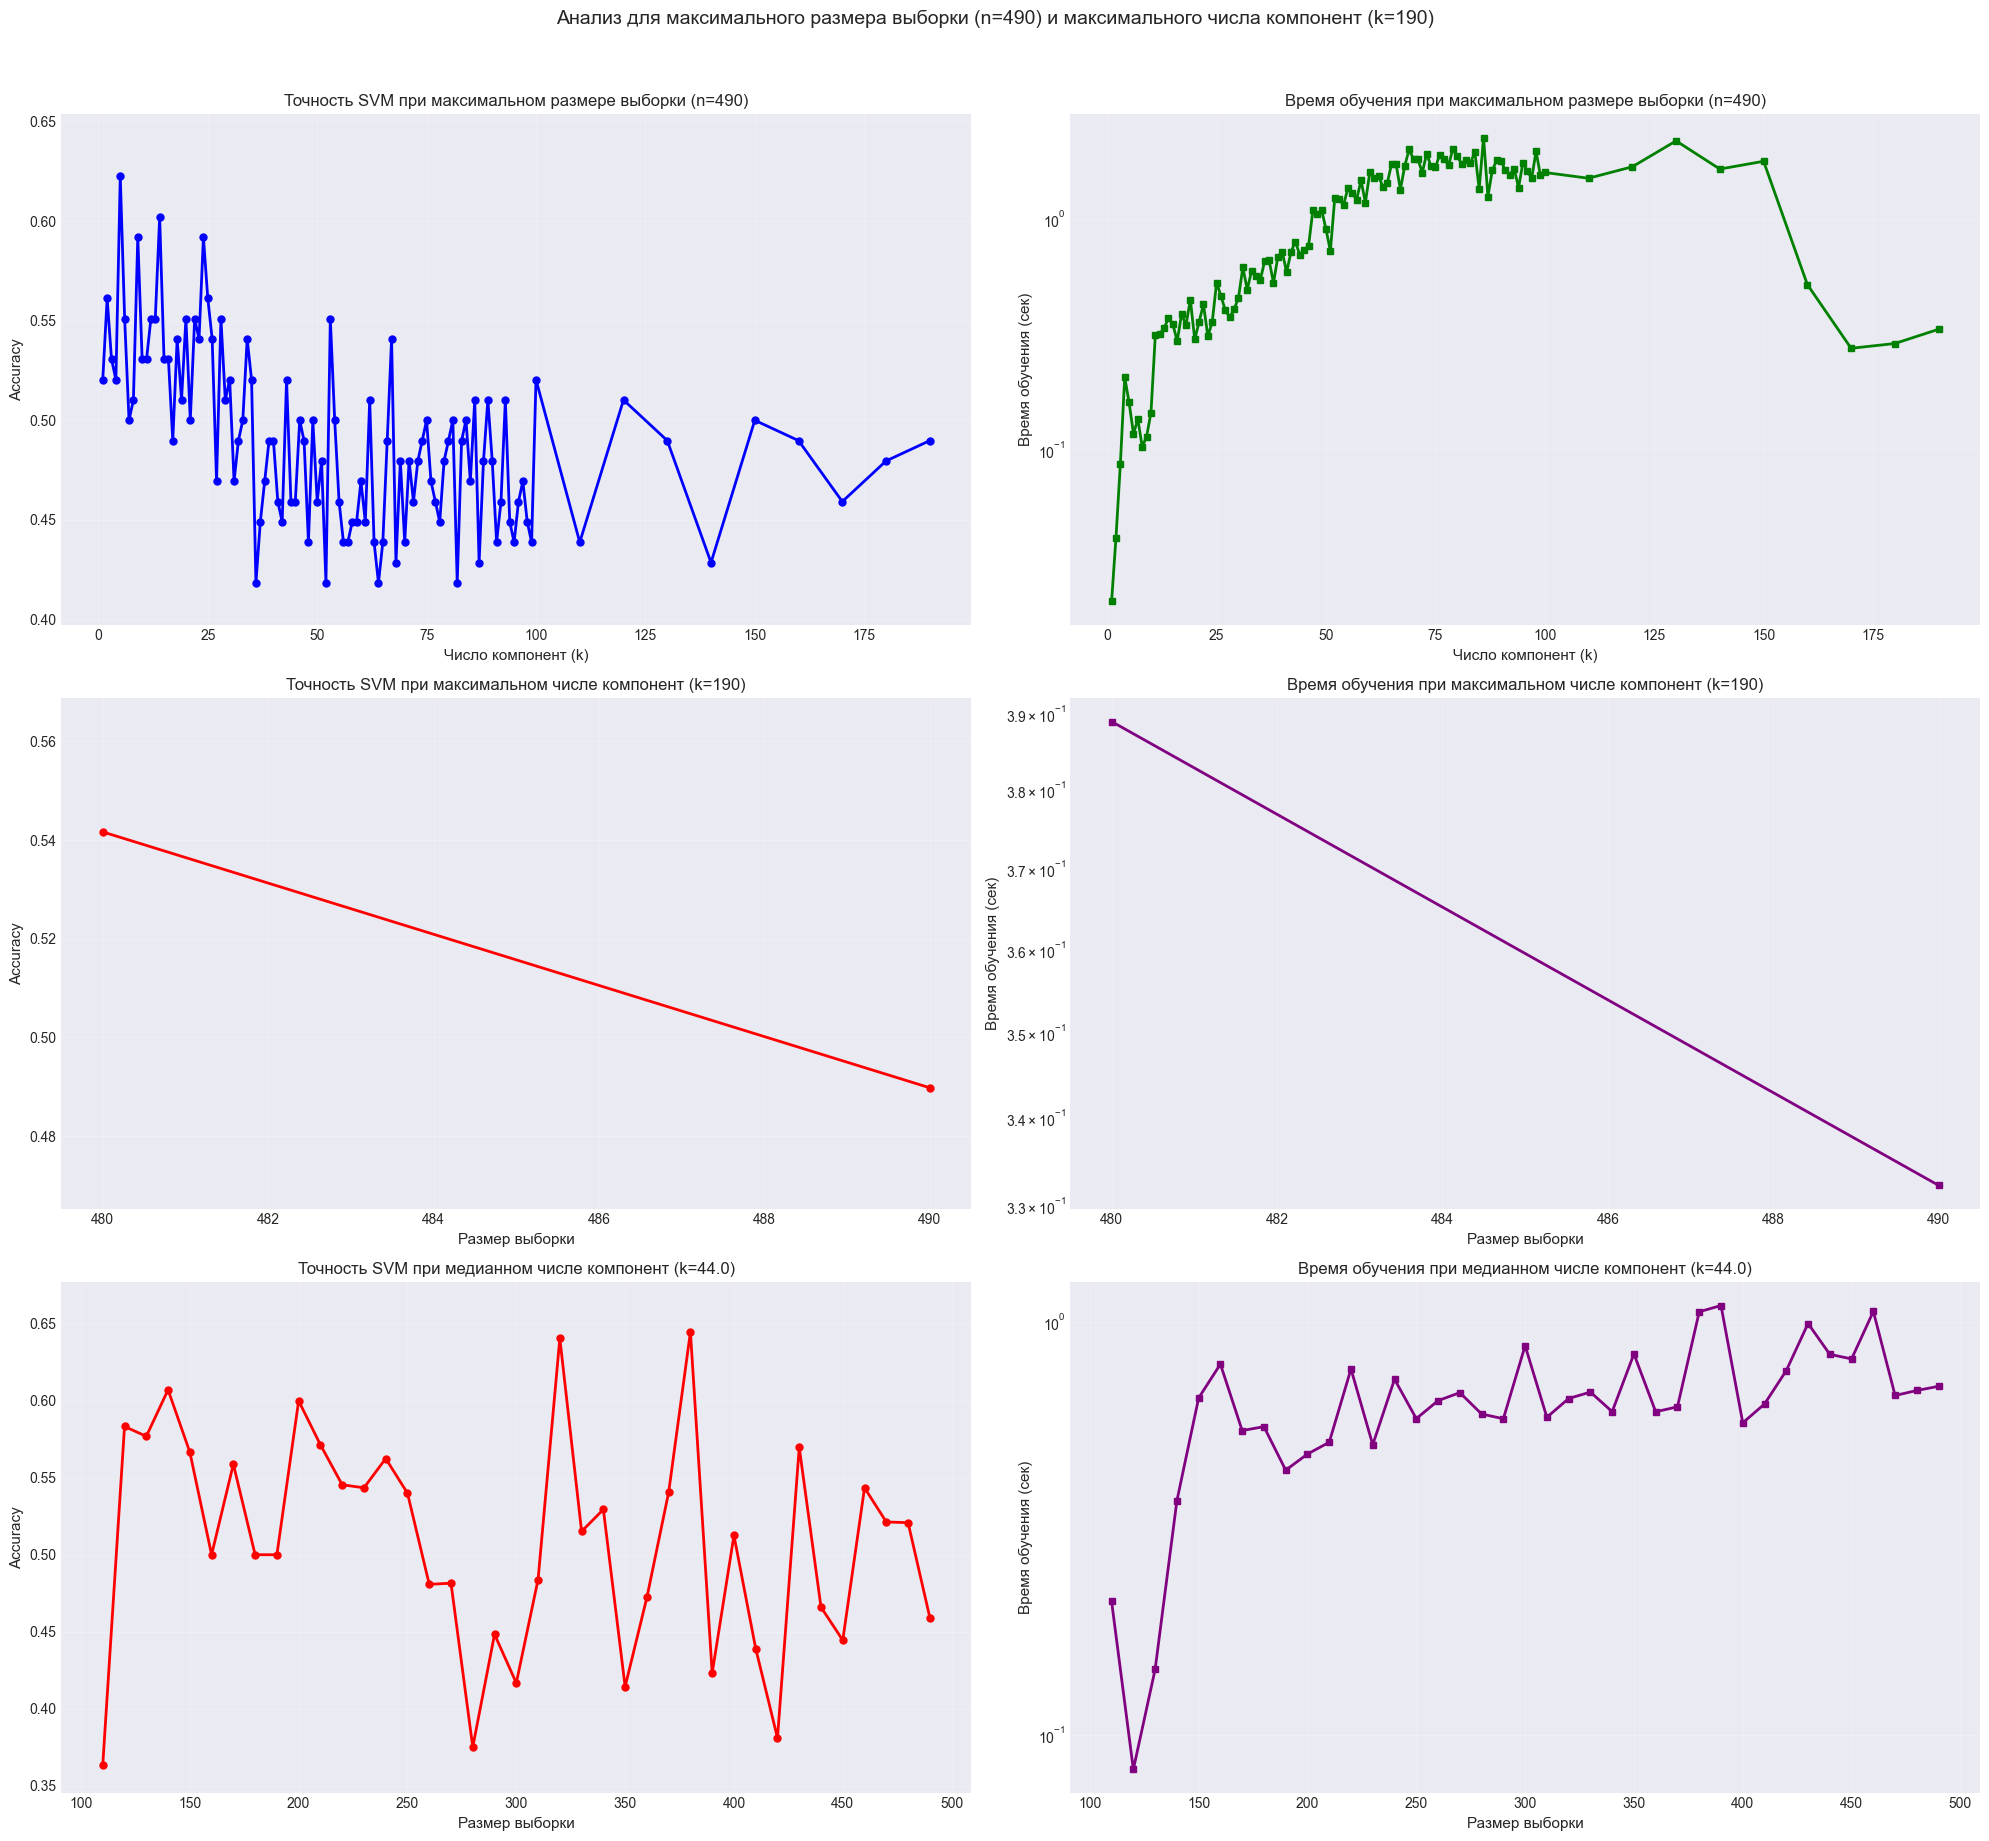

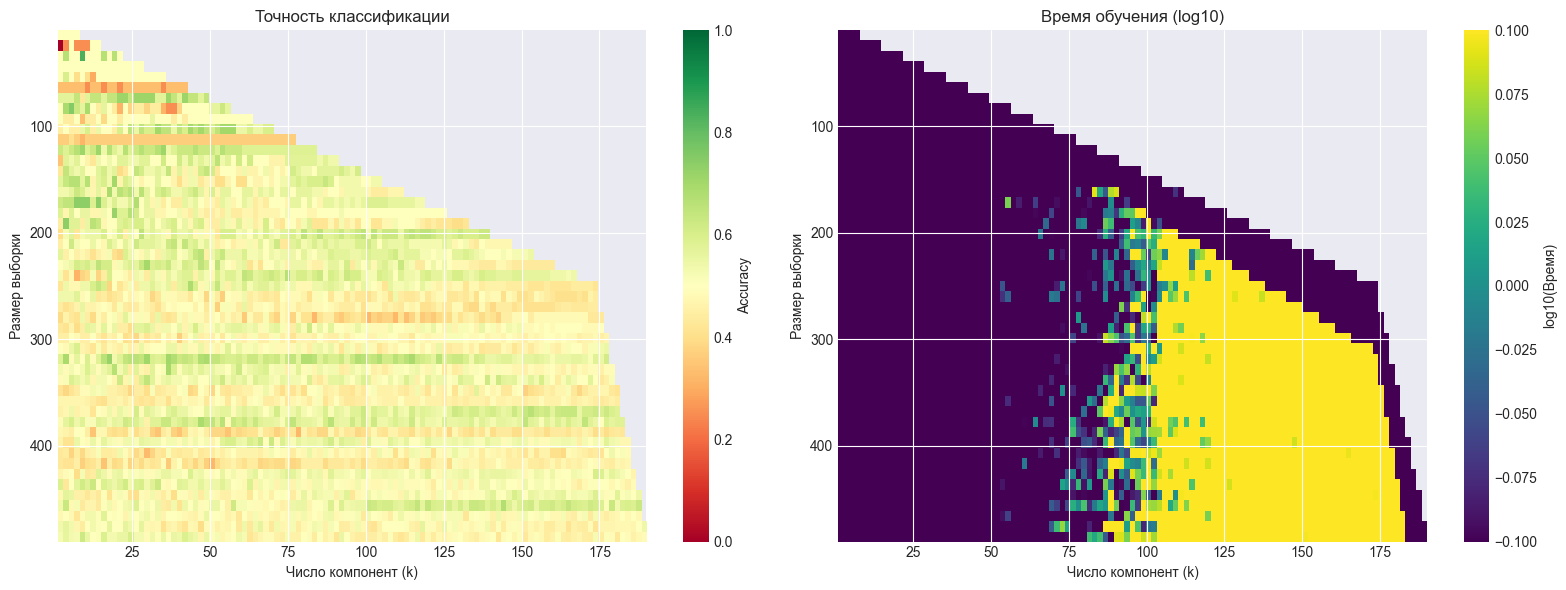

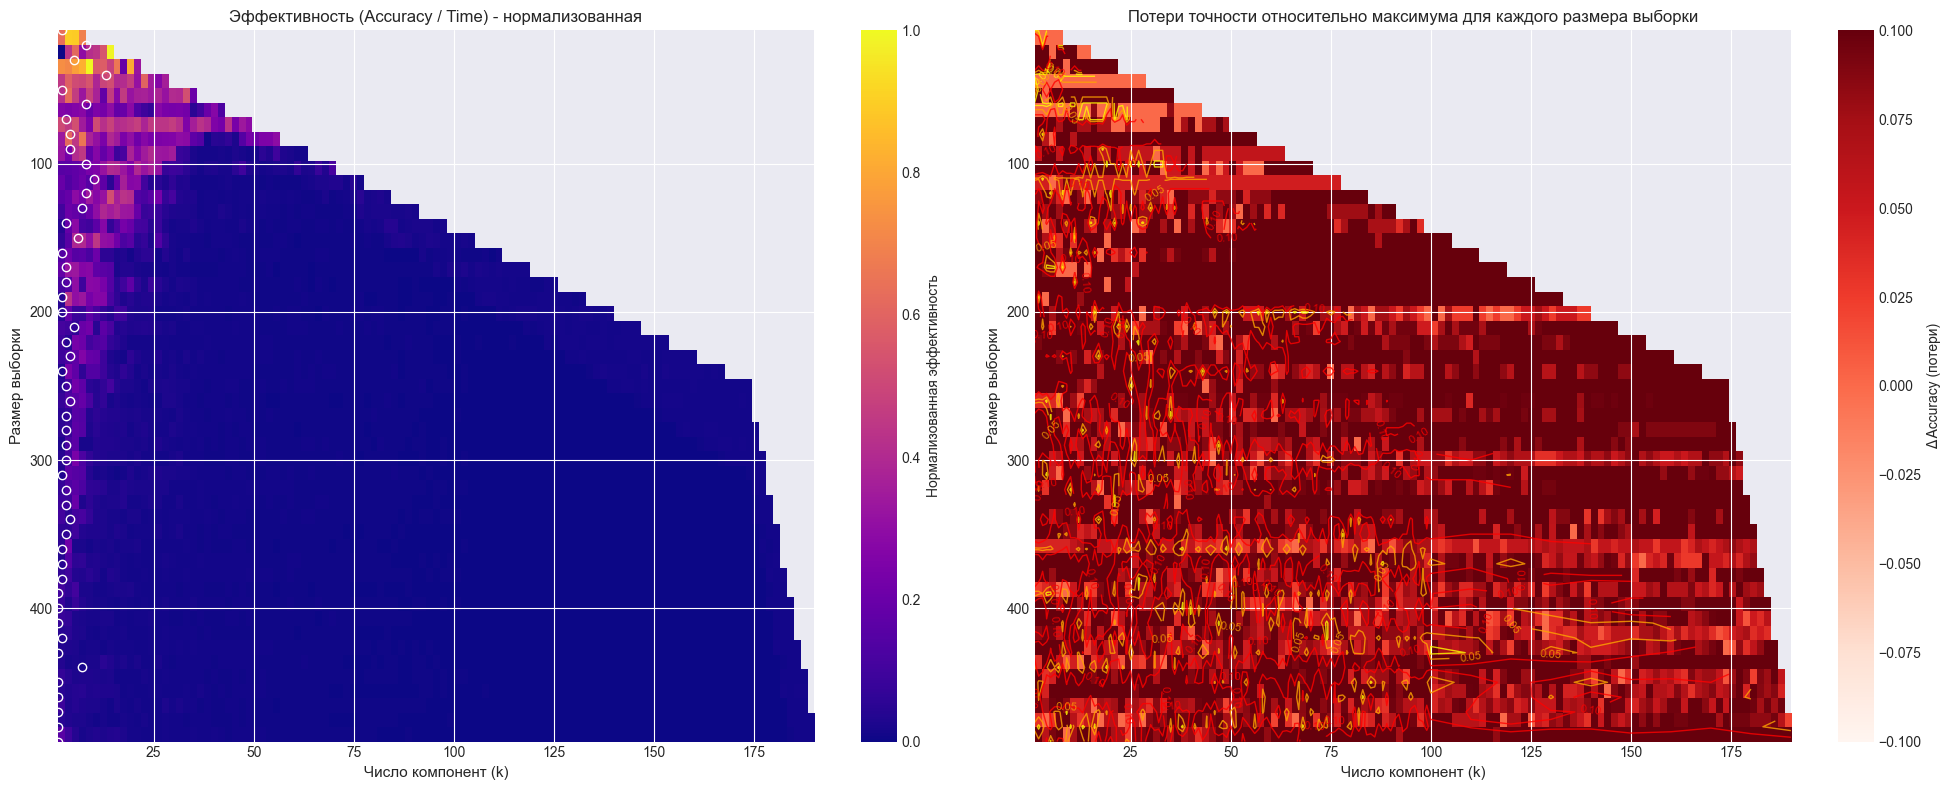

In [126]:
results_pca_svc_df['total_time'] = (results_pca_svc_df['delta_pca_fit'] + 
                                   results_pca_svc_df['delta_pca_transform'] + 
                                   results_pca_svc_df['delta_svc_fit'] + 
                                   results_pca_svc_df['delta_svc_predict'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

accuracy_by_dim = results_pca_svc_df.groupby('dim')['accuracy'].agg(['mean', 'min', 'max']).reset_index()

axes[0].plot(accuracy_by_dim['dim'], accuracy_by_dim['mean'], 
             'o-', color='blue', linewidth=2, markersize=4, label='Средняя')
axes[0].plot(accuracy_by_dim['dim'], accuracy_by_dim['min'], 
             's--', color='red', linewidth=1.5, markersize=3, label='Минимальная', alpha=0.7)
axes[0].plot(accuracy_by_dim['dim'], accuracy_by_dim['max'], 
             '^--', color='green', linewidth=1.5, markersize=3, label='Максимальная', alpha=0.7)

axes[0].fill_between(accuracy_by_dim['dim'], accuracy_by_dim['min'], accuracy_by_dim['max'], 
                     alpha=0.2, color='gray', label='Разброс')

axes[0].set_xlabel('Число главных компонент (k)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Статистика точности по числу компонент', fontsize=12)
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.2)
axes[0].axhline(y=0.95, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[0].set_ylim([accuracy_by_dim['min'].min() * 0.95, min(1.02, accuracy_by_dim['max'].max() * 1.05)])

accuracy_by_size = results_pca_svc_df.groupby('size')['accuracy'].agg(['mean', 'min', 'max']).reset_index()

axes[1].plot(accuracy_by_size['size'], accuracy_by_size['mean'], 
             'o-', color='blue', linewidth=2, markersize=4, label='Средняя')
axes[1].plot(accuracy_by_size['size'], accuracy_by_size['min'], 
             's--', color='red', linewidth=1.5, markersize=3, label='Минимальная', alpha=0.7)
axes[1].plot(accuracy_by_size['size'], accuracy_by_size['max'], 
             '^--', color='green', linewidth=1.5, markersize=3, label='Максимальная', alpha=0.7)

axes[1].fill_between(accuracy_by_size['size'], accuracy_by_size['min'], accuracy_by_size['max'], 
                     alpha=0.2, color='gray', label='Разброс')

axes[1].set_xlabel('Размер выборки', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Статистика точности по размеру выборки', fontsize=12)
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.2)
axes[1].axhline(y=0.95, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[1].set_ylim([accuracy_by_size['min'].min() * 0.95, min(1.02, accuracy_by_size['max'].max() * 1.05)])

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))

all_sizes = results_pca_svc_df['size'].unique()
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', 'd']

selected_sizes = all_sizes[::max(1, len(all_sizes)//10)][:10]

for i, size in enumerate(selected_sizes):
    size_data = results_pca_svc_df[results_pca_svc_df['size'] == size].sort_values('dim')
    grouped = size_data.groupby('dim')['accuracy'].mean().reset_index()
    ax.plot(grouped['dim'], grouped['accuracy'], 
            marker=markers[i % len(markers)], markersize=4, linewidth=1.5,
            label=f'Размер={size}')

ax.set_xlabel('Число главных компонент (k)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Зависимость точности SVM от числа компонент PCA для разных размеров выборки', fontsize=12)
ax.legend(title='Размер выборки', fontsize=9, loc='best')
ax.grid(True, alpha=0.2)
ax.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, linewidth=1)

all_accuracies = results_pca_svc_df['accuracy']
ax.set_ylim([all_accuracies.min() * 0.95, min(1.02, all_accuracies.max() * 1.05)])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

time_by_dim = results_pca_svc_df.groupby('dim')['total_time'].agg(['mean', 'min', 'max']).reset_index()

axes[0].plot(time_by_dim['dim'], time_by_dim['mean'], 
             'o-', color='purple', linewidth=2, markersize=4, label='Среднее')
axes[0].plot(time_by_dim['dim'], time_by_dim['min'], 
             's--', color='orange', linewidth=1.5, markersize=3, label='Минимальное', alpha=0.7)
axes[0].plot(time_by_dim['dim'], time_by_dim['max'], 
             '^--', color='brown', linewidth=1.5, markersize=3, label='Максимальное', alpha=0.7)

axes[0].fill_between(time_by_dim['dim'], time_by_dim['min'], time_by_dim['max'], 
                     alpha=0.2, color='gray', label='Разброс')

axes[0].set_xlabel('Число главных компонент (k)', fontsize=11)
axes[0].set_ylabel('Время обучения (сек)', fontsize=11)
axes[0].set_title('Статистика времени обучения по числу компонент', fontsize=12)
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.2)

time_by_size = results_pca_svc_df.groupby('size')['total_time'].agg(['mean', 'min', 'max']).reset_index()

axes[1].plot(time_by_size['size'], time_by_size['mean'], 
             'o-', color='purple', linewidth=2, markersize=4, label='Среднее')
axes[1].plot(time_by_size['size'], time_by_size['min'], 
             's--', color='orange', linewidth=1.5, markersize=3, label='Минимальное', alpha=0.7)
axes[1].plot(time_by_size['size'], time_by_size['max'], 
             '^--', color='brown', linewidth=1.5, markersize=3, label='Максимальное', alpha=0.7)

axes[1].fill_between(time_by_size['size'], time_by_size['min'], time_by_size['max'], 
                     alpha=0.2, color='gray', label='Разброс')

axes[1].set_xlabel('Размер выборки', fontsize=11)
axes[1].set_ylabel('Время обучения (сек)', fontsize=11)
axes[1].set_title('Статистика времени обучения по размеру выборки', fontsize=12)
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

max_size = results_pca_svc_df['size'].max()
max_dim = results_pca_svc_df['dim'].max()

fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle(f'Анализ для максимального размера выборки (n={max_size}) и максимального числа компонент (k={max_dim})', 
             fontsize=14, y=1.02)

max_size_data = results_pca_svc_df[results_pca_svc_df['size'] == max_size].sort_values('dim')
if len(max_size_data) > 0:
    axes[0, 0].plot(max_size_data['dim'], max_size_data['accuracy'], 
                    'o-', color='blue', linewidth=2, markersize=5)
    axes[0, 0].set_xlabel('Число компонент (k)', fontsize=11)
    axes[0, 0].set_ylabel('Accuracy', fontsize=11)
    axes[0, 0].set_title(f'Точность SVM при максимальном размере выборки (n={max_size})', fontsize=12)
    axes[0, 0].grid(True, alpha=0.2)
    axes[0, 0].axhline(y=0.95, color='r', linestyle='--', alpha=0.5, linewidth=1)
    axes[0, 0].set_ylim([max_size_data['accuracy'].min() * 0.95, 
                         min(1.02, max_size_data['accuracy'].max() * 1.05)])
else:
    axes[0, 0].text(0.5, 0.5, f'Нет данных для размера выборки {max_size}', 
                   ha='center', va='center', transform=axes[0, 0].transAxes)

if len(max_size_data) > 0:
    axes[0, 1].plot(max_size_data['dim'], max_size_data['total_time'], 
                    's-', color='green', linewidth=2, markersize=5)
    axes[0, 1].set_xlabel('Число компонент (k)', fontsize=11)
    axes[0, 1].set_ylabel('Время обучения (сек)', fontsize=11)
    axes[0, 1].set_title(f'Время обучения при максимальном размере выборки (n={max_size})', fontsize=12)
    axes[0, 1].grid(True, alpha=0.2)
    axes[0, 1].set_yscale('log')
else:
    axes[0, 1].text(0.5, 0.5, f'Нет данных для размера выборки {max_size}', 
                   ha='center', va='center', transform=axes[0, 1].transAxes)

max_dim_data = results_pca_svc_df[results_pca_svc_df['dim'] == max_dim].sort_values('size')
if len(max_dim_data) > 0:
    axes[1, 0].plot(max_dim_data['size'], max_dim_data['accuracy'], 
                    'o-', color='red', linewidth=2, markersize=5)
    axes[1, 0].set_xlabel('Размер выборки', fontsize=11)
    axes[1, 0].set_ylabel('Accuracy', fontsize=11)
    axes[1, 0].set_title(f'Точность SVM при максимальном числе компонент (k={max_dim})', fontsize=12)
    axes[1, 0].grid(True, alpha=0.2)
    axes[1, 0].axhline(y=0.95, color='r', linestyle='--', alpha=0.5, linewidth=1)
    axes[1, 0].set_ylim([max_dim_data['accuracy'].min() * 0.95, 
                         min(1.02, max_dim_data['accuracy'].max() * 1.05)])
else:
    axes[1, 0].text(0.5, 0.5, f'Нет данных для числа компонент {max_dim}', 
                   ha='center', va='center', transform=axes[1, 0].transAxes)

if len(max_dim_data) > 0:
    axes[1, 1].plot(max_dim_data['size'], max_dim_data['total_time'], 
                    's-', color='purple', linewidth=2, markersize=5)
    axes[1, 1].set_xlabel('Размер выборки', fontsize=11)
    axes[1, 1].set_ylabel('Время обучения (сек)', fontsize=11)
    axes[1, 1].set_title(f'Время обучения при максимальном числе компонент (k={max_dim})', fontsize=12)
    axes[1, 1].grid(True, alpha=0.2)
    axes[1, 1].set_yscale('log')
else:
    axes[1, 1].text(0.5, 0.5, f'Нет данных для числа компонент {max_dim}', 
                   ha='center', va='center', transform=axes[1, 1].transAxes)

median_dim = results_pca_svc_df['dim'].median()
median_dim_data = results_pca_svc_df[results_pca_svc_df['dim'] == median_dim].sort_values('size')

if len(median_dim_data) > 0:
    axes[2, 0].plot(median_dim_data['size'], median_dim_data['accuracy'], 
                    'o-', color='red', linewidth=2, markersize=5)
    axes[2, 0].set_xlabel('Размер выборки', fontsize=11)
    axes[2, 0].set_ylabel('Accuracy', fontsize=11)
    axes[2, 0].set_title(f'Точность SVM при медианном числе компонент (k={median_dim})', fontsize=12)
    axes[2, 0].grid(True, alpha=0.2)
    axes[2, 0].axhline(y=0.95, color='r', linestyle='--', alpha=0.5, linewidth=1)
    axes[2, 0].set_ylim([median_dim_data['accuracy'].min() * 0.95, 
                         min(1.02, median_dim_data['accuracy'].max() * 1.05)])
else:
    axes[2, 0].text(0.5, 0.5, f'Нет данных для числа компонент {median_dim}', 
                   ha='center', va='center', transform=axes[2, 0].transAxes)

if len(median_dim_data) > 0:
    axes[2, 1].plot(median_dim_data['size'], median_dim_data['total_time'], 
                    's-', color='purple', linewidth=2, markersize=5)
    axes[2, 1].set_xlabel('Размер выборки', fontsize=11)
    axes[2, 1].set_ylabel('Время обучения (сек)', fontsize=11)
    axes[2, 1].set_title(f'Время обучения при медианном числе компонент (k={median_dim})', fontsize=12)
    axes[2, 1].grid(True, alpha=0.2)
    axes[2, 1].set_yscale('log')
else:
    axes[2, 1].text(0.5, 0.5, f'Нет данных для числа компонент {median_dim}', 
                   ha='center', va='center', transform=axes[2, 1].transAxes)

plt.tight_layout()
plt.show()

accuracy_pivot = results_pca_svc_df.pivot_table(
    index='size', 
    columns='dim', 
    values='accuracy',
    aggfunc='mean'
)

time_pivot = results_pca_svc_df.pivot_table(
    index='size', 
    columns='dim', 
    values='total_time',
    aggfunc='mean'
)

accuracy_min = accuracy_pivot.values.min()
accuracy_max = accuracy_pivot.values.max()
accuracy_range = accuracy_max - accuracy_min

vmin_acc = max(0.0, accuracy_min - 0.05 * accuracy_range)
vmax_acc = min(1.0, accuracy_max + 0.05 * accuracy_range)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im1 = axes[0].imshow(accuracy_pivot.values, aspect='auto', cmap='RdYlGn', 
                     vmin=vmin_acc, vmax=vmax_acc,
                     extent=[accuracy_pivot.columns.min(), accuracy_pivot.columns.max(),
                             accuracy_pivot.index.max(), accuracy_pivot.index.min()])
axes[0].set_xlabel('Число компонент (k)')
axes[0].set_ylabel('Размер выборки')
axes[0].set_title('Точность классификации')
plt.colorbar(im1, ax=axes[0], label='Accuracy')

X, Y = np.meshgrid(accuracy_pivot.columns, accuracy_pivot.index)
contour = axes[0].contour(X, Y, accuracy_pivot.values, levels=[0.85, 0.90, 0.95], 
                          colors=['yellow', 'orange', 'red'], linewidths=1, alpha=0.8)
axes[0].clabel(contour, inline=True, fontsize=8, fmt='%.2f')

log_time = np.log10(time_pivot.values + 1e-10)
vmin_time = log_time.min()
vmax_time = log_time.max()
time_range = vmax_time - vmin_time

im2 = axes[1].imshow(log_time, aspect='auto', cmap='viridis',
                     vmin=vmin_time - 0.1 * time_range,
                     vmax=vmax_time + 0.1 * time_range,
                     extent=[time_pivot.columns.min(), time_pivot.columns.max(),
                             time_pivot.index.max(), time_pivot.index.min()])
axes[1].set_xlabel('Число компонент (k)')
axes[1].set_ylabel('Размер выборки')
axes[1].set_title('Время обучения (log10)')
cbar = plt.colorbar(im2, ax=axes[1])
cbar.set_label('log10(Время)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ax1 = axes[0]
efficiency_pivot = accuracy_pivot.copy()
for i in range(efficiency_pivot.shape[0]):
    for j in range(efficiency_pivot.shape[1]):
        efficiency_pivot.iloc[i, j] = accuracy_pivot.iloc[i, j] / (time_pivot.iloc[i, j] + 0.001)

efficiency_normalized = (efficiency_pivot - efficiency_pivot.min().min()) / (efficiency_pivot.max().max() - efficiency_pivot.min().min())

im1 = ax1.imshow(efficiency_normalized.values, aspect='auto', cmap='plasma',
                 extent=[efficiency_pivot.columns.min(), efficiency_pivot.columns.max(),
                         efficiency_pivot.index.max(), efficiency_pivot.index.min()])
ax1.set_xlabel('Число компонент (k)', fontsize=11)
ax1.set_ylabel('Размер выборки', fontsize=11)
ax1.set_title('Эффективность (Accuracy / Time) - нормализованная', fontsize=12)
plt.colorbar(im1, ax=ax1, label='Нормализованная эффективность')

for idx, size in enumerate(efficiency_pivot.index):
    max_eff_idx = efficiency_pivot.loc[size].idxmax()
    x_pos = list(efficiency_pivot.columns).index(max_eff_idx)
    y_pos = list(efficiency_pivot.index).index(size)
    ax1.plot(efficiency_pivot.columns[x_pos], efficiency_pivot.index[y_pos], 
             'o', markersize=6, markeredgecolor='white', markerfacecolor='none', 
             markeredgewidth=1)

ax2 = axes[1]
accuracy_diff_pivot = accuracy_pivot.copy()
for idx, size in enumerate(accuracy_pivot.index):
    max_acc_for_size = accuracy_pivot.loc[size].max()
    accuracy_diff_pivot.loc[size] = max_acc_for_size - accuracy_pivot.loc[size]

im2 = ax2.imshow(accuracy_diff_pivot.values, aspect='auto', cmap='Reds',
                 vmin=0, vmax=accuracy_diff_pivot.values.max(),
                 extent=[accuracy_diff_pivot.columns.min(), accuracy_diff_pivot.columns.max(),
                         accuracy_diff_pivot.index.max(), accuracy_diff_pivot.index.min()])
ax2.set_xlabel('Число компонент (k)', fontsize=11)
ax2.set_ylabel('Размер выборки', fontsize=11)
ax2.set_title('Потери точности относительно максимума для каждого размера выборки', fontsize=12)
plt.colorbar(im2, ax=ax2, label='Δ Accuracy (потери)')

X_diff, Y_diff = np.meshgrid(accuracy_diff_pivot.columns, accuracy_diff_pivot.index)
contour_diff = ax2.contour(X_diff, Y_diff, accuracy_diff_pivot.values, 
                           levels=[0.01, 0.05, 0.10], colors=['yellow', 'orange', 'red'], 
                           linewidths=1, alpha=0.8)
ax2.clabel(contour_diff, inline=True, fontsize=8, fmt='%.2f')

plt.tight_layout()
plt.show()

Опишите в выводе как ведет себя качество решения задачи и время работы в зависимости от числа компонент в PCA.  

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Ну, надеюсь достаточно очевидно, что время растёт при увеличении числа компонент, хотя под конец оно почему-то упало, но думаю это скорее исключение, чем закономерность, думаю если заново запустить, там будут колебания. А вот точность &mdash; полный хаос какой-то. Нуу, максимальная более-менее стабильно падает после первого пика, т.е. скорее всего идёт переобучение дальше, хотя опять-таки, PCA вообще не смотрит на отклик и непонятно. Вероятно, компоненты ЛЗ, из-за чего и наблюдаются периодические просадки в точности. Ну вообще ладно, не полный хаос, там вначаааале стабильный рост, а вот дальше по достижению шумовых признаков &mdash; вот там шум

# Калибровка вероятностей

Иногда в задаче классификации важно знать уверенность отнесения к тому или иному классу. В SVM за это отвечает параметр отступа (margin), который можно посчитать, используя model.decision_function(X). Именно отступ до разделяющей кривой пытается максимизироавть модель во время обучения. Однако по нему сложно утверждать с какой вероятностью объект относится к тому или иному классу.

Чтобы это понять давайте построим следующую кривую:
1) нормализуем отступы так, чтобы они лежали в диапазоне от 0 до 1;

2) разделим все объекты на бины по нормализованному оступу (например на [0, 0.1), [0.1, 0.2)...);

3) для каждого бина построим точку с координатой x - равной среднему значению нормализованного оступа внутри бина, и с координатой y - равной доле объектов класса 1 внутри бина.

Заметим теперь, что если бы нормализованный отступ приблизительно равнялся вероятности отнесения к классу, то бину [x, x + 0.1) должна была бы соответствовать точка с координатой Х принадлежащей [x, x + 0.1) и координатой Y в том же диапазоне. Таким образом, чем лучше скоры модели показывают вероятность отнесения к классу 1, тем больше калибровочная кривая похожа на прямую из точки (0, 0) в (1, 1).

Кроме того построим аналогично кривую для логистической регрессии, взяв вместо нормализованного отступа - вероятность отнесения к первому классу через predict_proba. Так как логистическая регрессия оптимизирует LogLoss и её выходом уже являются вероятности отнесения к классам, будем ожидать что её кривая хорошо ляжет на прямую из (0, 0) в (1, 1).

In [198]:
from sklearn.datasets import make_classification
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

In [199]:
X, y = make_classification(n_samples=10000, n_classes=2, weights=[1, 1], random_state=69)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [200]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
svm_decision = svm_model.decision_function(X_test)

In [201]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
svm_normalized = scaler.fit_transform(svm_decision.reshape(-1, 1)).flatten()
svm_normalized[svm_normalized > 1.0] = 1.0

In [202]:
bins_count = 10
svm_prob_true, svm_prob_pred = calibration_curve(y_test, svm_normalized, n_bins=bins_count, strategy='uniform')

In [203]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

In [204]:
lr_prob_true, lr_prob_pred = calibration_curve(y_test, lr_probs, n_bins=bins_count, strategy='uniform')

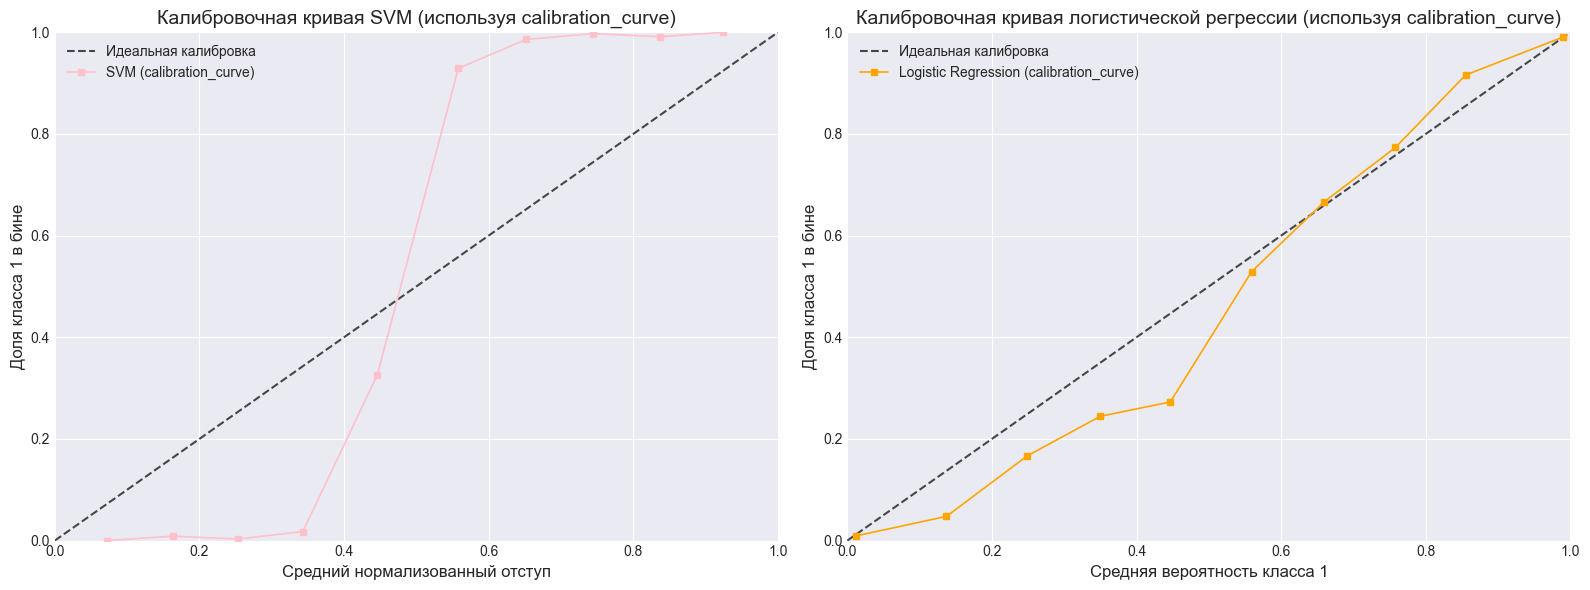

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка', alpha=0.7)
ax1.plot(svm_prob_pred, svm_prob_true, 's-', color='pink', linewidth=1.2, markersize=4, label='SVM (calibration_curve)')
ax1.set_xlabel('Средний нормализованный отступ', fontsize=12)
ax1.set_ylabel('Доля класса 1 в бине', fontsize=12)
ax1.set_title('Калибровочная кривая SVM (используя calibration_curve)', fontsize=14)
ax1.grid(True)
ax1.legend()
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

ax2 = axes[1]
ax2.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка', alpha=0.7)
ax2.plot(lr_prob_pred, lr_prob_true, 's-', color='orange', linewidth=1.2, markersize=4, label='Logistic Regression (calibration_curve)')
ax2.set_xlabel('Средняя вероятность класса 1', fontsize=12)
ax2.set_ylabel('Доля класса 1 в бине', fontsize=12)
ax2.set_title('Калибровочная кривая логистической регрессии (используя calibration_curve)', fontsize=14)
ax2.grid(True)
ax2.legend()
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

-----------
<font color="white" style="opacity:0.2025"></font>

Вот мы и увидели проблему, линия отступов не ложится на пунктирную линию, что означает что оступы не соотвествуют реальным вероятностям отнесения к тому или иному классу.  

   Но не всё пропало! Из отступов всё ещё можно получить вероятность отнесения к классу. Для этого существует  такая процедура как калибровка вероятностей, при которой отступ для каждого объекта преобразовывается таким образом, чтобы соответствовать вероятности класса. После такого преобразования, полученное число становится интерпретируемой мерой уверенности модели.



## <font color='DarkOrange'>**Задание 5 [2 баллa]**</font>

В данном задании Вам прелагается обучить логистическую регрессию на отступах модели, которая по оступу (margin) предсказывала бы класс. Именно вероятности этой калибровочной модели и будут нашими верными оценками вероятности класса для объекта:

$p(y_i | x_i) = p(y_i | margin_i)$

Для этого Вам потребуется написать несложный класс CalibratingLogisticRegression. И проверить что новые предсказания дают правильную калибровочную кривую

In [206]:
class CalibratingLogisticRegression:
    def __init__(self):
        self.__model = LogisticRegression()
    
    def fit(self, x, y):
        assert len(x.shape) == 1 or x.shape[1] == 1
        X = np.asarray(x)
        y = np.asarray(y)
        if X.ndim == 1: X = X.reshape(-1, 1)
        self.__model.fit(X, y)
        return self

    def predict_proba(self, x):
        assert len(x.shape) == 1 or x.shape[1] == 1
        X = np.asarray(x)
        if X.ndim == 1: X = X.reshape(-1, 1)
        return self.__model.predict_proba(X)[:, 1]

Калибровочную модель и исходную модель нельзя учить на одних и тех же данных, чтобы избежать переобучения. (распределение отступов на обучении и тестовой выборке, скорее всего очень сильно отличается)

In [207]:
model = SVC()
N = len(X_train) // 2
model.fit(X_train[:N], y_train[:N])

SVC()

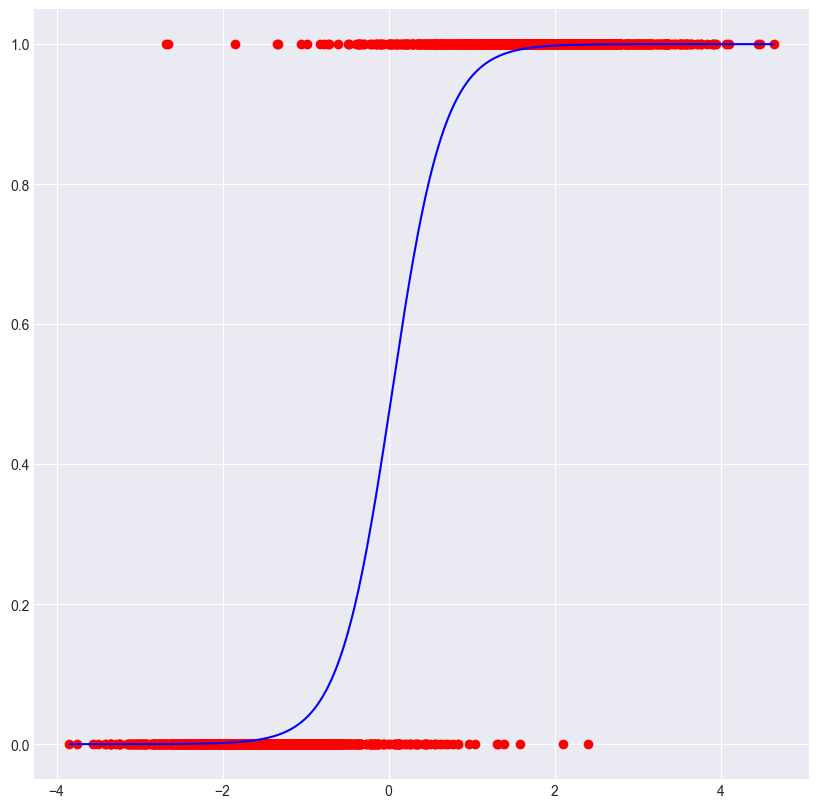

In [208]:
margin = model.decision_function(X_train[N:])


# Учим калибровочную модель на второй половине данных
calibrating_model = CalibratingLogisticRegression()
calibrating_model.fit(margin, y_train[N:])
prob = calibrating_model.predict_proba(margin)


# Как это выглядит на обучении
margin_sorted, probs_sorted_by_margin = zip(*sorted(zip(margin, prob)))
plt.figure(figsize=(10, 10))
plt.plot(margin, y_train[N:], 'ro')
plt.plot(margin_sorted, probs_sorted_by_margin, 'b')
plt.show()

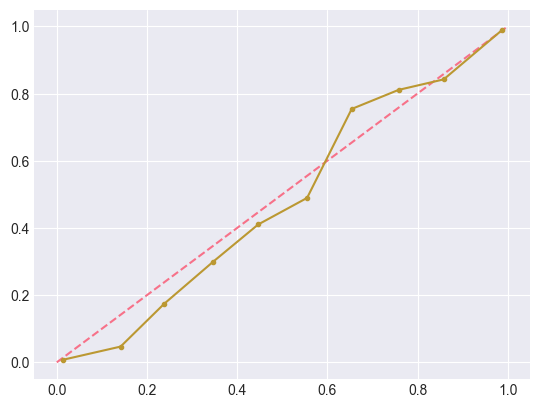

In [209]:
probs = calibrating_model.predict_proba(model.decision_function(X_test))
# reliability diagram
fop, mpv = calibration_curve(y_test, probs, n_bins=10)
# plot perfectly calibrated
plt.plot([0, 1], [0, 1], linestyle='--')
# plot calibrated reliability
plt.plot(mpv, fop, marker='.')
plt.show()

Обратите внимание, что кривая для откалиброванных отступов должня также строиться для бинов и состоянть из n_bins точек. Если у Вас получилось кривая из трёх точек, Вы что-то сделали неправильно :)

**Сделайте выводы** о полученной модели. В каких задачах калибровка вероятностей могла бы быть полезной?

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Моделька теперь не просто точной в плане классфикации, но и неплохой в плане интерпретации, ибо теперь у нас корректные вероятности, ну то есть до этого у SVM был прям треш по отступам, переведённым в вероятность, регрессия же изначально была неплоха и вероятности были около нормы, теперь мы используем для классификации монотонненькую кривую, соответственно, зачем калибровали-то? Ну например мы хотим не просто отранжировать данные, но и, например, на основе значений что-то поинтерпретировать: кредитный скоринг, боляки там всякие, вероятность рака, например, и т.д., тогда у нас корректные абсолютные значения шанса получаются, которые используются активно в интерпретации весов логистической регрессии, что в целом хорошо для подбора правильного порога